# A1 — Vision Transformers: classificação de lesões de pele (HAM10000)

**Execução:** Google Colab com GPU T4.

| | Valor |
|---|---|
| Tempo estimado de execução | [preencher com o TOTAL da célula "Resumo de tempo e memória"] |
| Pico de memória da GPU (VRAM) | [preencher] |
| Pico de RAM do processo | [preencher] |

> Valores medidos na execução de referência (runtime limpo, modo Drive). O detalhamento por
> etapa fica em `report_assets/tempos_execucao.csv`.

In [1]:
import time
_T_INICIO_NOTEBOOK = time.perf_counter()  # tempo total do notebook (R8)
TEMPOS = []  # registro das etapas cronometradas (ver src/utils.cronometrar)

REPO_URL = "https://github.com/anacaetano02/Deep-Learning-Visao-Computacional.git"
SUBPASTA = "A1_vision_transformers"
REPO_DIR = "/content/repo"

if not REPO_URL:
    raise ValueError("Defina REPO_URL com a URL do seu repositório git antes de continuar.")

import os
import subprocess

PROJECT_DIR = os.path.join(REPO_DIR, SUBPASTA)

if not os.path.isdir(os.path.join(REPO_DIR, ".git")):
    # --filter=blob:none: baixa só os metadados de commit/árvore, os
    # arquivos (blobs) de fora do sparse-checkout nunca são transferidos.
    # --sparse liga o modo cone do sparse-checkout (mais rápido e mais
    # simples de configurar que listar padrões manualmente).
    subprocess.run(
        ["git", "clone", "--filter=blob:none", "--sparse", "--depth", "1", REPO_URL, REPO_DIR],
        check=True,
    )
    subprocess.run(["git", "sparse-checkout", "set", SUBPASTA], cwd=REPO_DIR, check=True)
else:
    # Repositório já clonado nesta sessão do Colab (variável de estado que
    # sobrevive a reexecuções de célula, só não a reinício de runtime) —
    # git pull traz commits novos em vez de simplesmente pular, para
    # mudanças feitas no código depois do clone inicial não ficarem presas
    # do lado de fora.
    print(f"Repositório já clonado em '{REPO_DIR}' — buscando mudanças mais recentes...")
    subprocess.run(["git", "pull"], cwd=REPO_DIR, check=True)

TEMPOS.append({"etapa": "clone/pull do repositório", "segundos": round(time.perf_counter() - _T_INICIO_NOTEBOOK, 1),
               "pico_vram_gb": None, "pico_ram_processo_gb": None})

Repositório já clonado em '/content/repo' — buscando mudanças mais recentes...


In [2]:
import importlib, sys

# Recarrega os módulos do projeto já importados (depois do git pull)
for nome in sorted(m for m in sys.modules if m == "src" or m.startswith("src.")):
    importlib.reload(sys.modules[nome])


In [3]:
# Onde salvar dados e artefatos desta execução.
from pathlib import Path

SALVAR_NO_DRIVE = True  # AJUSTE conforme sua preferência.

if SALVAR_NO_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    # AJUSTE: caminho da pasta de saída dentro do seu Drive.
    BASE_DIR = Path("/content/drive/MyDrive/deep_learning_visao_computacional/A1_vision_transformers")
else:
    BASE_DIR = Path("/content/A1_vision_transformers_saida")

print(f"BASE_DIR = {BASE_DIR} (Drive: {SALVAR_NO_DRIVE})")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE_DIR = /content/drive/MyDrive/deep_learning_visao_computacional/A1_vision_transformers (Drive: True)


In [4]:
# Estrutura de saída (Drive/BASE_DIR). Tudo como Path, para usar o operador "/".
DIR_DADOS_RAW = BASE_DIR / "data" / "raw"
DIR_DADOS_PROCESSADOS = BASE_DIR / "data" / "processed"
DIR_OUTPUTS = BASE_DIR / "outputs"
DIR_CHECKPOINTS = DIR_OUTPUTS / "checkpoints"
DIR_REPORT_ASSETS = DIR_OUTPUTS / "report_assets"
DIR_EXPERIMENTOS = DIR_OUTPUTS / "experimentos"  # histórico por época + experimentos.csv
DIR_RUNS = BASE_DIR / "runs"  # logs do TensorBoard

LOCAL_DIR = Path("/content/local_data")  # cópia local, nunca no Drive
# ultimo.pt do ViT-base (~1 GB por época) fica no disco local: não enche a cota do Drive
DIR_CHECKPOINTS_LOCAL = LOCAL_DIR / "checkpoints"

for d in (DIR_DADOS_RAW, DIR_DADOS_PROCESSADOS, DIR_CHECKPOINTS, DIR_REPORT_ASSETS, DIR_EXPERIMENTOS, DIR_RUNS, LOCAL_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Diretórios prontos:")
for d in (DIR_DADOS_RAW, DIR_DADOS_PROCESSADOS, DIR_CHECKPOINTS, DIR_REPORT_ASSETS, DIR_EXPERIMENTOS, DIR_RUNS, LOCAL_DIR):
    print(f"  {d}")

Diretórios prontos:
  /content/drive/MyDrive/deep_learning_visao_computacional/A1_vision_transformers/data/raw
  /content/drive/MyDrive/deep_learning_visao_computacional/A1_vision_transformers/data/processed
  /content/drive/MyDrive/deep_learning_visao_computacional/A1_vision_transformers/outputs/checkpoints
  /content/drive/MyDrive/deep_learning_visao_computacional/A1_vision_transformers/outputs/report_assets
  /content/drive/MyDrive/deep_learning_visao_computacional/A1_vision_transformers/outputs/experimentos
  /content/drive/MyDrive/deep_learning_visao_computacional/A1_vision_transformers/runs
  /content/local_data


In [5]:
import json
import sys
import polars as pl
import numpy as np
import torch
from transformers import AutoImageProcessor

if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

from src.data import (
    extrair_metadados,
    deduplicar_por_imagem,
    montar_split_por_lesao,
    validar_split,
    salvar_split,
    carregar_split,
    COLUNA_GRUPO,
    COLUNAS_SPLIT,
    montar_transforms,
    preparar_dataloaders,
    ORDEM_SPLITS,
    INDICE_PARA_CLASSE,
    CLASSE_PARA_INDICE,
    CLASSES,
    computar_pesos,
)

from src.eda import (
    tabela_vazamento,
    tabela_contagens,
    tabela_classes_por_split,
    figura_batch,
)

from src.utils import cronometrar, tabela_tempos, testar
from src.models import carregar_vit_pretreinado, congelar
from src.transformer import (
    atencao_produto_escalado,
    ScaledDotProductAttention,
    MultiHeadAttention,
    TransformerEncoderBlock,
    PatchEmbedding,
    VisionTransformer,
)
from src.training import (
    fixar_seeds,
    grupos_weight_decay,
    treinar_modelo,
    carregar_melhor_modelo,
    registrar_experimento,
    carregar_experimentos,
)

from src.evaluation import (
    ler_marca, 
    prever, 
    calcular_metricas, 
    plotar_matriz_confusao, 
    plotar_curvas, 
    ids_do_split,
    baseline_dummy, 
    bootstrap_pareado, 
    descrever_diferenca, 
    tabela_comparativa, 
    tabela_por_classe,
    exemplos_de_erro,
    sigla,
)
from src.attention import (
    atencoes_de_indices,
    desnormalizar,
    mapa_cls,
    massa_no_cls,
    concentracao,
    patches_escuros,
    fracao_em_patches_escuros,
    escolher_exemplos,
    plotar_comparacao,
    plotar_heads,
    titulos_exemplos,
)

print("Módulos do projeto importados com sucesso.")

Módulos do projeto importados com sucesso.


In [6]:
SEED = 42
fixar_seeds(SEED)  # random, numpy, torch, cuda; o shuffle do treino usa seed=SEED no DataLoader
PROPORCOES_SPLIT = {"test": 0.15, "validation": 0.15, "train": 0.70}

# Modelos (decisões registradas no REQUISITOS.md)
CHECKPOINT_PRE = "google/vit-base-patch16-224"
# Versão do checkpoint fixada pelo SHA do commit no Hub (último commit: 05/09/2023), como o dataset.
# Para conferir: from huggingface_hub import HfApi; HfApi().model_info(CHECKPOINT_PRE).sha
REVISAO_CHECKPOINT_PRE = "3f49326eb077187dfe1c2a2bb15fbd74e6ab91e3"
TAMANHO_ZERO, PATCH_ZERO = 128, 16

# ViT do zero: UMA config usada nos testes, no smoke test e no treino real (R5).
# Valores de partida (a justificar no R5): lr/wd típicos de ViT pequeno treinado do zero;
# paciência maior que o padrão porque o F1 macro de validação oscila (poucas imagens de df/vasc).
CONFIG_ZERO = {
    "modelo": {"img": TAMANHO_ZERO, "patch": PATCH_ZERO, "d": 192, "h": 3, "profundidade": 6,
               "mlp": 768, "dropout": 0.1, "tipo_pe": "aprendivel"},
    "treino": {"epochs": 50, "lr": 3e-4, "weight_decay": 0.05, "frac_warmup": 0.1,
               "paciencia_early_stopping": 10, "min_delta": 0.0, "clip_grad_norm_max": 1.0},
}

# ViT pré-treinado: mesmo formato. "modelo" guarda só o congelamento (checkpoint, revisão, tamanho
# da imagem e semente entram pelos metadados de carregar_vit_pretreinado).
# Valores de partida (a justificar no R5): lr/wd da aula 5; poucas épocas com paciência = épocas,
# para o cosseno chegar a zero e a seleção ser pelo melhor F1 (no vit_zero_v1, o early stopping com
# o F1 oscilando cortou o cosseno no meio).
CONFIG_PRE = {
    "modelo": {"blocos_treinaveis": 12},
    "treino": {"epochs": 8, "lr": 5e-5, "weight_decay": 0.01, "frac_warmup": 0.1,
               "paciencia_early_stopping": 8, "min_delta": 0.0, "clip_grad_norm_max": 1.0},
}
BATCH_SIZE = {"pre": 32, "zero": 64}  # a ajustar na Fase 4 conforme a memória da T4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("AVISO: sem GPU. No Colab, use Ambiente de execução > Alterar o tipo > GPU T4.")

from datetime import datetime
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
print(f"RUN_ID = {RUN_ID}")

Semente 42 configurada (priorizar_velocidade=True).
GPU: Tesla T4
RUN_ID = 20260930_233243


In [7]:
from datasets import load_dataset

# Versão do dataset fixada pelo hash do commit no Hub (último commit: 25/01/2023).
# O split e o idx_original do CSV dependem da ordem das linhas desta versão.
# Para conferir o hash atual: HfApi().dataset_info("marmal88/skin_cancer").sha
NOME_DATASET = "marmal88/skin_cancer"
REVISAO_DATASET = "bdd59e10860746202dfdc452e0ac3a9eaa25268d"

with cronometrar("download/carregamento do dataset (HF)", TEMPOS):
    dataset = load_dataset(NOME_DATASET, revision=REVISAO_DATASET)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


README.md:   0%|          | 0.00/3.24k [00:00<?, ?B/s]

data/train-00000-of-00005-7eed077f2f8e6d(…): reconstructing file:   0%|          |  0.00B /  521MB            

data/train-00000-of-00005-7eed077f2f8e6d(…): downloading bytes:           |  0.00B            

data/train-00001-of-00005-50ba64fd20294b(…): reconstructing file:   0%|          |  0.00B /  525MB            

...

data/test-00000-of-00001-61e7cf54bf274ae(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/9577 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2492 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1285 [00:00<?, ? examples/s]

[tempo] download/carregamento do dataset (HF): 183.9s | pico VRAM 0.00 GB (reservada 0.00 GB) | pico RAM do processo 2.61 GB


## Dados: deduplicação e novo split por lesão

> **A escrever (R1, R10):** por que o split do Hugging Face foi descartado e o que foi feito no lugar.
> Use os números das tabelas abaixo (`contagens`, `vazamento_antes_*`, `vazamento_depois_*`, `dx_por_split_*`)
> e responda: quanto do teste/validação já estava no treino? Por que o vazamento por `lesion_id` importa
> além do por `image_id`? Como o novo split evita isso, e qual a limitação para as classes raras?

In [8]:
with cronometrar("metadados, deduplicação, split e tabelas", TEMPOS):
    # Etapas: bruto -> deduplicado -> com split
    df_bruto = extrair_metadados(dataset)
    df_dedup = deduplicar_por_imagem(df_bruto)
    df_split = montar_split_por_lesao(df_dedup, PROPORCOES_SPLIT, seed=SEED)
    validar_split(df_split)

    execucoes = {
        "vazamento_antes_image_id":   (df_bruto, "split_original", "image_id"),
        "vazamento_antes_lesion_id":  (df_bruto, "split_original", COLUNA_GRUPO),
        "vazamento_depois_image_id":  (df_split, "split", "image_id"),
        "vazamento_depois_lesion_id": (df_split, "split", COLUNA_GRUPO),
    }
    tabelas = {
        nome: tabela_vazamento(df, coluna, coluna_split)
        for nome, (df, coluna_split, coluna) in execucoes.items()
    }
    tabelas["contagens"] = tabela_contagens(df_bruto, df_dedup)
    tabelas["dx_por_split_antes"] = tabela_classes_por_split(df_bruto, "split_original")
    tabelas["dx_por_split_depois"] = tabela_classes_por_split(df_split)

    # 1) Testes de sanidade ANTES de gravar: se falharem, nenhum CSV errado vai para outputs/
    contagens = dict(zip(tabelas["contagens"]["metrica"], tabelas["contagens"]["valor"]))
    assert contagens["linhas_bruto"] == 13_354, f"Bruto com {contagens['linhas_bruto']} linhas"
    assert contagens["duplicatas_removidas"] == 3_339, f"{contagens['duplicatas_removidas']} duplicatas removidas"
    assert contagens[f"{COLUNA_GRUPO}_unicos_deduplicado"] == contagens[f"{COLUNA_GRUPO}_unicos"], (
        "A deduplicação perdeu lesões"
    )

    # O "antes" tem de bater exatamente com o que já foi medido (linhas de B afetadas,
    # pares train_vs_validation, train_vs_test, validation_vs_test); o "depois" tem de ser zero
    esperado = {"vazamento_antes_image_id": [2105, 1025, 209], "vazamento_antes_lesion_id": [2272, 1132, 386]}
    for nome, linhas in esperado.items():
        obtido = tabelas[nome]["linhas_de_B_afetadas"].to_list()
        assert obtido == linhas, f"{nome}: esperava {linhas}, obtive {obtido}. Algo mudou na extração."
    for nome in ("vazamento_depois_image_id", "vazamento_depois_lesion_id"):
        assert tabelas[nome]["linhas_de_B_afetadas"].sum() == 0, f"{nome} deveria ser zero"

    # 2) Só então exibe (sem cortar colunas) e grava nos artefatos do relatório
    with pl.Config(tbl_cols=-1, tbl_width_chars=250):
        for nome, tabela in tabelas.items():
            print(nome)
            display(tabela)
            tabela.write_csv(DIR_REPORT_ASSETS / f"{nome}.csv")

Split OK: zero vazamento de image_id, lesion_id entre os pares de splits.
vazamento_antes_image_id


par,grupos_em_comum,linhas_de_B_afetadas,pct_linhas_de_B
str,i64,i64,f64
"""train_vs_validation""",2105,2105,84.47
"""train_vs_test""",1025,1025,79.77
"""validation_vs_test""",209,209,16.26


vazamento_antes_lesion_id


par,grupos_em_comum,linhas_de_B_afetadas,pct_linhas_de_B
str,i64,i64,f64
"""train_vs_validation""",2113,2272,91.17
"""train_vs_test""",1069,1132,88.09
"""validation_vs_test""",360,386,30.04


vazamento_depois_image_id


...

dx_por_split_antes


dx,n_imagens_train,n_imagens_validation,n_imagens_test,n_lesoes_train,n_lesoes_validation,n_lesoes_test,pct_n_imagens_train,pct_n_imagens_validation,pct_n_imagens_test,pct_n_lesoes_train,pct_n_lesoes_validation,pct_n_lesoes_test
str,u32,u32,u32,u32,u32,u32,f64,f64,f64,f64,f64,f64
"""actinic_keratoses""",315,82,42,223,74,42,3.29,3.29,3.27,3.09,3.18,3.44
"""basal_cell_carcinoma""",487,124,67,317,115,63,5.09,4.98,5.21,4.39,4.94,5.16
"""benign_keratosis-like_lesions""",1048,275,142,703,256,131,10.94,11.04,11.05,9.73,10.99,10.73
"""dermatofibroma""",110,30,14,72,27,14,1.15,1.2,1.09,1.0,1.16,1.15
"""melanocytic_Nevi""",6405,1666,858,5207,1579,825,66.88,66.85,66.77,72.06,67.8,67.57
"""melanoma""",1076,280,144,608,245,130,11.24,11.24,11.21,8.41,10.52,10.65
"""vascular_lesions""",136,35,18,96,33,16,1.42,1.4,1.4,1.33,1.42,1.31


dx_por_split_depois


dx,n_imagens_train,n_imagens_validation,n_imagens_test,n_lesoes_train,n_lesoes_validation,n_lesoes_test,pct_n_imagens_train,pct_n_imagens_validation,pct_n_imagens_test,pct_n_lesoes_train,pct_n_lesoes_validation,pct_n_lesoes_test
str,u32,u32,u32,u32,u32,u32,f64,f64,f64,f64,f64,f64
"""actinic_keratoses""",232,47,48,160,34,34,3.31,3.16,3.14,3.06,3.04,3.04
"""basal_cell_carcinoma""",365,79,70,229,49,49,5.22,5.31,4.58,4.38,4.38,4.38
"""benign_keratosis-like_lesions""",769,162,168,509,109,109,10.99,10.88,11.0,9.73,9.73,9.73
"""dermatofibroma""",82,18,15,51,11,11,1.17,1.21,0.98,0.98,0.98,0.98
"""melanocytic_Nevi""",4667,997,1041,3783,810,810,66.68,66.96,68.17,72.33,72.32,72.32
"""melanoma""",783,167,163,430,92,92,11.19,11.22,10.67,8.22,8.21,8.21
"""vascular_lesions""",101,19,22,68,15,15,1.44,1.28,1.44,1.3,1.34,1.34


[tempo] metadados, deduplicação, split e tabelas: 4.5s | pico VRAM 0.00 GB (reservada 0.00 GB) | pico RAM do processo 2.61 GB


In [9]:
with cronometrar("conferência do split versionado", TEMPOS):
    # Split versionado (dentro do repo, só leitura) x split gerado (fora do repo).
    # Gerar dentro do clone quebraria o próximo git pull quando o arquivo for commitado.
    SPLIT_VERSIONADO = Path(PROJECT_DIR) / "split_lesoes.csv"
    SPLIT_GERADO = DIR_DADOS_PROCESSADOS / "split_lesoes.csv"

    if SPLIT_VERSIONADO.exists():
        df_split_salvo = carregar_split(SPLIT_VERSIONADO)
        validar_split(df_split_salvo)
        # O split recalculado acima tem de ser idêntico ao versionado
        recalculado = df_split.select(COLUNAS_SPLIT).sort("image_id")
        assert df_split_salvo.sort("image_id").equals(recalculado), (
            "O split recalculado difere do versionado: o dataset ou o código do split mudou"
        )
        print("Split versionado confere com o recalculado.")
    else:
        salvar_split(df_split, SPLIT_GERADO)
        print(f"Copie {SPLIT_GERADO} para A1_vision_transformers/split_lesoes.csv no repositório e faça commit.")

    SPLIT_OFICIAL = df_split_salvo if SPLIT_VERSIONADO.exists() else df_split
    print(f"Split oficial: {SPLIT_OFICIAL.height} imagens")

Split carregado de /content/repo/A1_vision_transformers/split_lesoes.csv (10015 linhas)
Split OK: zero vazamento de image_id, lesion_id entre os pares de splits.
Split versionado confere com o recalculado.
Split oficial: 10015 imagens
[tempo] conferência do split versionado: 0.0s | pico VRAM 0.00 GB (reservada 0.00 GB) | pico RAM do processo 2.61 GB


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

pre   train      (32, 3, 224, 224) torch.float32 [-1.00, 1.00] rótulos [0, 1, 2, 3, 5, 6]


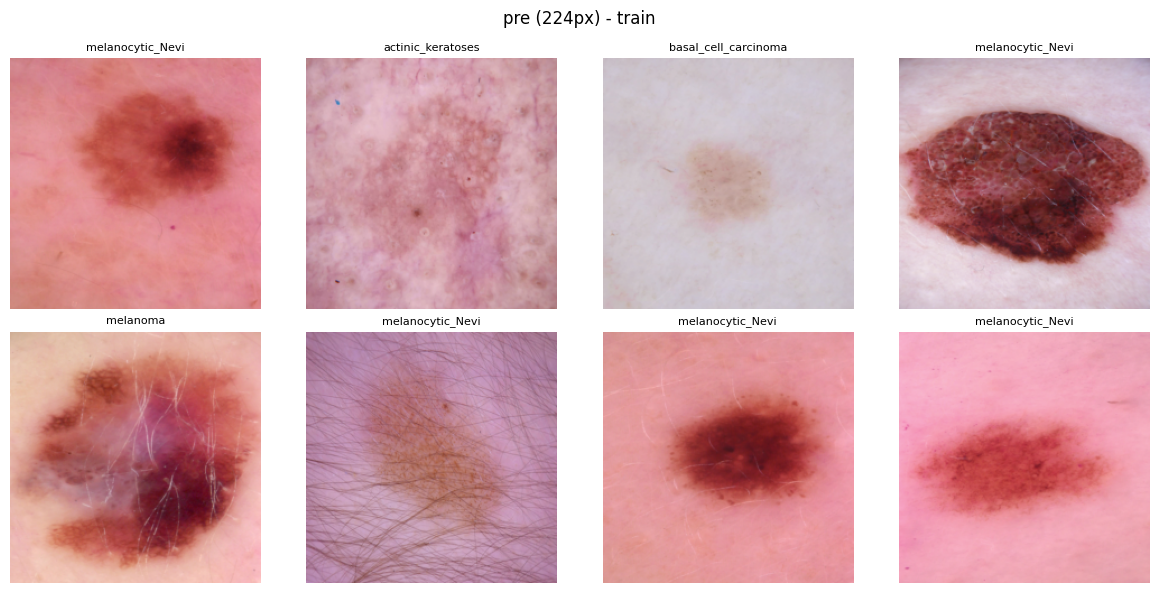

pre   validation (32, 3, 224, 224) torch.float32 [-1.00, 1.00] rótulos [0, 1, 2, 4, 6]


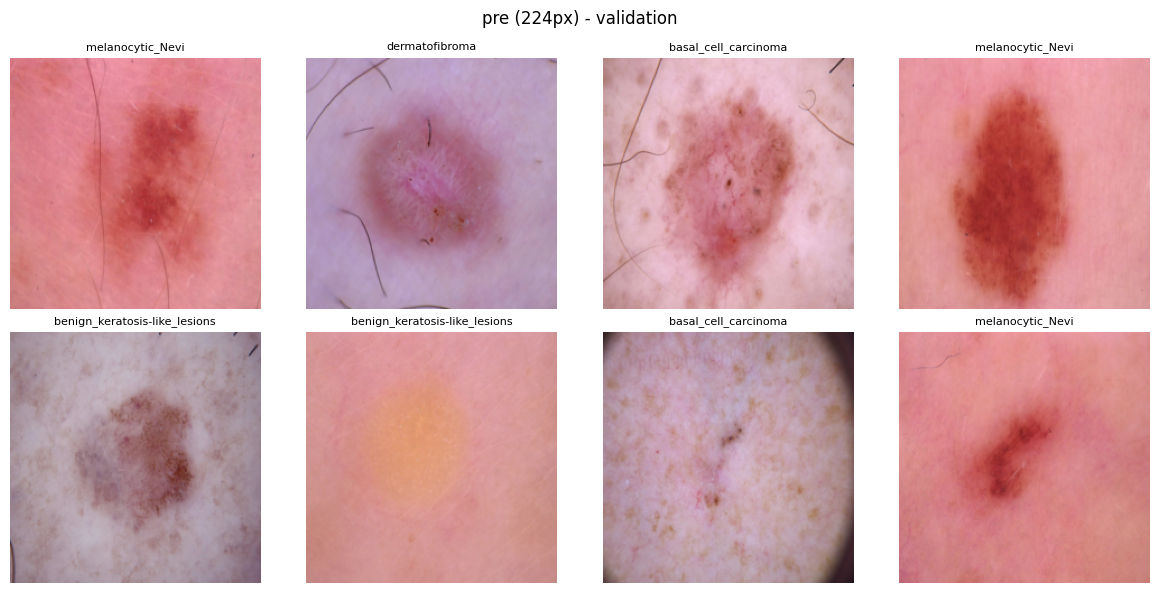

zero  train      (64, 3, 128, 128) torch.float32 [-1.00, 1.00] rótulos [0, 1, 2, 3, 5, 6]


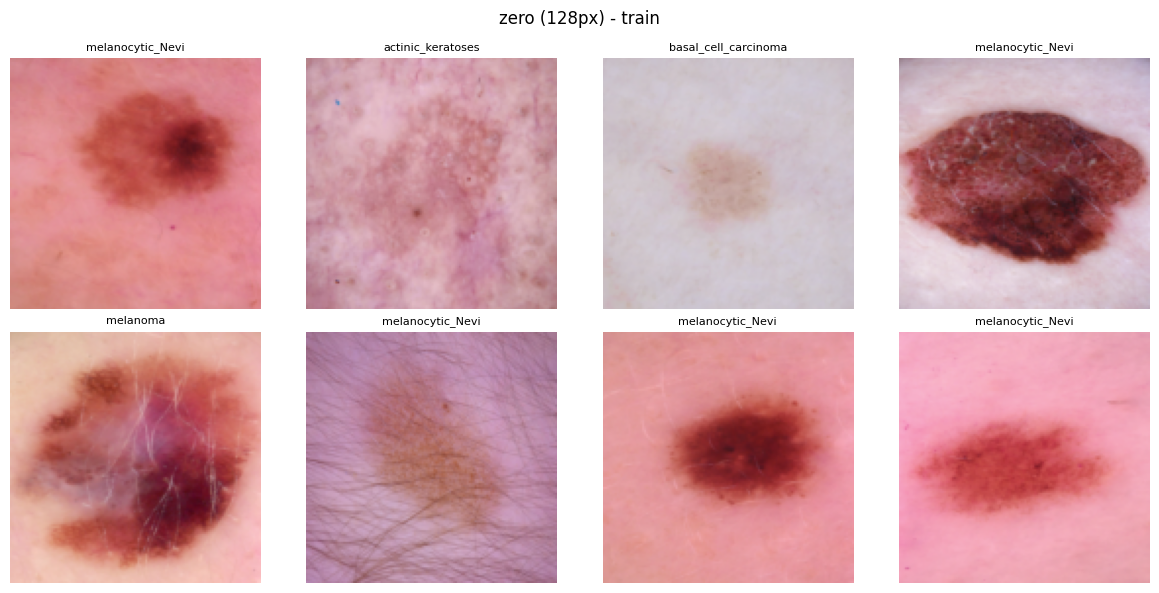

zero  validation (64, 3, 128, 128) torch.float32 [-1.00, 1.00] rótulos [0, 1, 2, 3, 4, 5, 6]


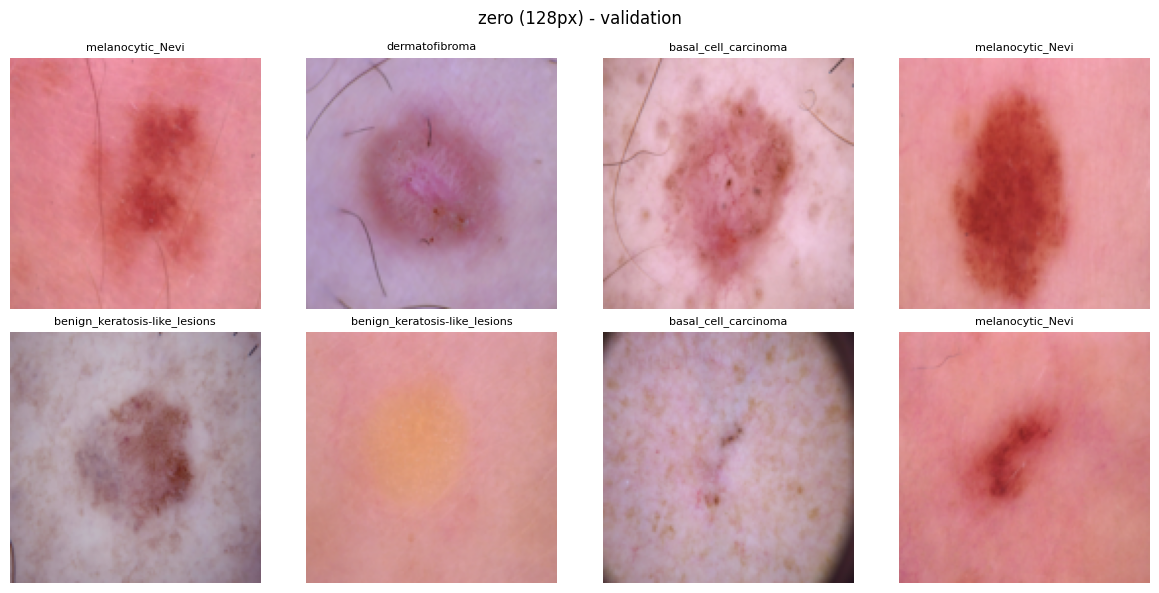

[tempo] DataLoaders e teste de 1 batch: 17.2s | pico VRAM 0.00 GB (reservada 0.00 GB) | pico RAM do processo 2.61 GB


In [10]:
import matplotlib.pyplot as plt

with cronometrar("DataLoaders e teste de 1 batch", TEMPOS):
    # DataLoaders dos dois modelos sobre o mesmo split; só tamanho e batch mudam.
    # Normalização e tamanho do pré-treinado vêm do processor do checkpoint.
    proc = AutoImageProcessor.from_pretrained(CHECKPOINT_PRE)
    # list(...): o processor pode devolver lista ou tupla; lista != tupla em Python
    MEDIA, DESVIO = list(proc.image_mean), list(proc.image_std)
    TAMANHO_PRE = int(proc.size["height"])
    assert (MEDIA, DESVIO, TAMANHO_PRE) == ([0.5] * 3, [0.5] * 3, 224), (
        f"processor diferente do esperado: {MEDIA}, {DESVIO}, {TAMANHO_PRE}"
    )

    configs = {
        "pre":  {"tamanho": TAMANHO_PRE,  "batch_size": BATCH_SIZE["pre"]},
        "zero": {"tamanho": TAMANHO_ZERO, "batch_size": BATCH_SIZE["zero"]},
    }
    loaders = {
        nome: preparar_dataloaders(dataset, SPLIT_OFICIAL, media=MEDIA, desvio=DESVIO, seed=SEED, **cfg)
        for nome, cfg in configs.items()
    }

    # Teste de sanidade: 1 batch de treino (com augmentation) e 1 de validação (sem)
    for nome, cfg in configs.items():
        t = cfg["tamanho"]
        assert [len(loaders[nome][s].dataset) for s in ORDEM_SPLITS] == [6999, 1489, 1527]
        for split in ("train", "validation"):
            x, y = next(iter(loaders[nome][split]))
            print(f"{nome:5s} {split:10s} {tuple(x.shape)} {x.dtype} [{x.min():.2f}, {x.max():.2f}] rótulos {sorted(y.unique().tolist())}")
            assert x.shape[1:] == (3, t, t) and x.dtype == torch.float32
            assert -1.0 <= x.min() and x.max() <= 1.0, "normalização fora de [-1, 1]"
            # Sem o Normalize os valores ficariam em [0, 1]: só com ele aparecem negativos
            assert x.min() < 0, "nenhum valor negativo: o Normalize não foi aplicado?"
            assert y.dtype == torch.int64 and 0 <= y.min() and y.max() <= 6

            fig = figura_batch(x, y, INDICE_PARA_CLASSE, MEDIA, DESVIO, f"{nome} ({t}px) - {split}")
            fig.savefig(DIR_REPORT_ASSETS / f"batch_{nome}_{split}.png", dpi=120, bbox_inches="tight")
            display(fig)
            plt.close(fig)

## ViT do zero: testes dos módulos (R11–R19)

Os módulos estão em `src/transformer.py`. Cada teste faz um `assert` (o notebook para se falhar)
e imprime uma linha `OK`. Os testes usam tensores aleatórios para as propriedades matemáticas e um
**batch real** do DataLoader do ViT do zero (128 px) para o modelo completo.

`torch.nn.functional.scaled_dot_product_attention` aparece **só como referência de teste**; o modelo
não a usa.

> **A escrever (R12):** o que é uma head, `head_i = Attention(X W_i^Q, X W_i^K, X W_i^V)`,
> `MHA = Concat(head_1..head_h) W^O`, por que `d_k = d/h` e o papel de `W^O`.

In [11]:
import torch.nn.functional as F

torch.manual_seed(SEED)
D, H = CONFIG_ZERO["modelo"]["d"], CONFIG_ZERO["modelo"]["h"]
N = (TAMANHO_ZERO // PATCH_ZERO) ** 2 + 1                          # 65 tokens (64 patches + CLS)
d_k = D // H

with cronometrar("testes do ViT do zero", TEMPOS):
    # --- R11: scaled dot-product attention ---------------------------------------------------
    q, k, v = (torch.randn(2, H, N, d_k) for _ in range(3))
    saida, pesos = ScaledDotProductAttention()(q, k, v)
    testar(f"R11 shapes: saída {tuple(saida.shape)}, pesos {tuple(pesos.shape)}",
           saida.shape == (2, H, N, d_k) and pesos.shape == (2, H, N, N))
    testar("R11 igual à referência F.scaled_dot_product_attention",
           torch.allclose(saida, F.scaled_dot_product_attention(q, k, v), atol=1e-5))
    testar("R11 cada linha dos pesos soma 1 e todos são >= 0",
           torch.allclose(pesos.sum(-1), torch.ones(2, H, N), atol=1e-5) and (pesos >= 0).all())

    mascara = torch.ones(N, N, dtype=torch.bool)
    mascara[:, 10:] = False                                        # só os 10 primeiros tokens visíveis
    saida_m, pesos_m = atencao_produto_escalado(q, k, v, mascara)
    v_alterado = v.clone()
    v_alterado[..., 10:, :] = 99.0
    testar("R11 máscara: posições mascaradas têm peso 0 e alterá-las não muda a saída",
           (pesos_m[..., 10:] == 0).all()
           and torch.allclose(saida_m, atencao_produto_escalado(q, k, v_alterado, mascara)[0]))

    # --- R12: multi-head com projeções independentes por head ---------------------------------
    mha = MultiHeadAttention(D, H).eval()
    x_tok = torch.randn(2, N, D)
    y, p = mha(x_tok)
    testar(f"R12 shapes: saída {tuple(y.shape)}, pesos {tuple(p.shape)}",
           y.shape == (2, N, D) and p.shape == (2, H, N, N))
    testar(f"R12 {len(mha.heads)} heads, cada uma com W_q/W_k/W_v próprios de {D}->{d_k}",
           len(mha.heads) == H and all(hd.w_q.out_features == d_k for hd in mha.heads)
           and not torch.equal(mha.heads[0].w_q.weight, mha.heads[1].w_q.weight))
    por_head = [F.scaled_dot_product_attention(hd.w_q(x_tok), hd.w_k(x_tok), hd.w_v(x_tok))
                for hd in mha.heads]
    testar("R12 saída = W_O(concat das heads calculadas separadamente)",
           torch.allclose(y, mha.w_o(torch.cat(por_head, dim=-1)), atol=1e-5))

OK  R11 shapes: saída (2, 3, 65, 64), pesos (2, 3, 65, 65)
OK  R11 igual à referência F.scaled_dot_product_attention
OK  R11 cada linha dos pesos soma 1 e todos são >= 0
OK  R11 máscara: posições mascaradas têm peso 0 e alterá-las não muda a saída
OK  R12 shapes: saída (2, 65, 192), pesos (2, 3, 65, 65)
OK  R12 3 heads, cada uma com W_q/W_k/W_v próprios de 192->64
OK  R12 saída = W_O(concat das heads calculadas separadamente)
[tempo] testes do ViT do zero: 0.1s | pico VRAM 0.00 GB (reservada 0.00 GB) | pico RAM do processo 2.61 GB


In [12]:
# --- R14–R19 com um batch REAL do DataLoader do ViT do zero -----------------------------------
x_real, y_real = next(iter(loaders["zero"]["train"]))              # (64, 3, 128, 128)

with cronometrar("testes do ViT do zero (batch real)", TEMPOS):
    bloco = TransformerEncoderBlock(D, H, CONFIG_ZERO["modelo"]["mlp"]).eval()
    saida_b, pesos_b = bloco(x_tok)
    testar(f"R14 TransformerEncoderBlock preserva o shape {tuple(saida_b.shape)}",
           saida_b.shape == x_tok.shape)

    patch_emb = PatchEmbedding(TAMANHO_ZERO, PATCH_ZERO, 3, D)
    tokens = patch_emb(x_real)
    patches_achatados = F.unfold(x_real, PATCH_ZERO, stride=PATCH_ZERO).transpose(1, 2)   # (B, 64, 3·16·16)
    via_linear = patches_achatados @ patch_emb.proj.weight.flatten(1).T + patch_emb.proj.bias
    testar(f"R15 PatchEmbedding {tuple(x_real.shape)} -> {tuple(tokens.shape)}",
           tokens.shape == (x_real.size(0), N - 1, D))
    testar("R15 Conv2d(kernel=stride=patch) == achatar cada patch + Linear",
           torch.allclose(tokens, via_linear, atol=1e-4))

    for tipo in ("aprendivel", "senoidal"):
        vit = VisionTransformer(**{**CONFIG_ZERO["modelo"], "tipo_pe": tipo}).eval()
        with torch.no_grad():
            logits, pesos_camadas = vit(x_real)
        n_param = sum(p.numel() for p in vit.parameters() if p.requires_grad)
        testar(f"R16/R17/R19 ViT[{tipo}]: logits {tuple(logits.shape)}, {len(pesos_camadas)} camadas de "
               f"pesos {tuple(pesos_camadas[0].shape)}, {n_param / 1e6:.2f}M parâmetros treináveis",
               logits.shape == (x_real.size(0), 7) and pesos_camadas[0].shape == (x_real.size(0), H, N, N))
    testar("R17 PE aprendível é parâmetro; senoidal é buffer (não treina)",
           isinstance(VisionTransformer(**{**CONFIG_ZERO["modelo"], "tipo_pe": "aprendivel"}).pos, torch.nn.Parameter)
           and not isinstance(vit.pos, torch.nn.Parameter) and "pos" in dict(vit.named_buffers()))

    vit = VisionTransformer(**CONFIG_ZERO["modelo"])
    F.cross_entropy(vit(x_real)[0], y_real).backward()
    sem_grad = [nome for nome, p in vit.named_parameters() if p.grad is None]
    testar(f"R19 gradiente chega a todos os parâmetros ({len(sem_grad)} sem grad)", not sem_grad)

OK  R14 TransformerEncoderBlock preserva o shape (2, 65, 192)
OK  R15 PatchEmbedding (64, 3, 128, 128) -> (64, 64, 192)
OK  R15 Conv2d(kernel=stride=patch) == achatar cada patch + Linear
OK  R16/R17/R19 ViT[aprendivel]: logits (64, 7), 6 camadas de pesos (64, 3, 65, 65), 2.83M parâmetros treináveis
OK  R16/R17/R19 ViT[senoidal]: logits (64, 7), 6 camadas de pesos (64, 3, 65, 65), 2.82M parâmetros treináveis
OK  R17 PE aprendível é parâmetro; senoidal é buffer (não treina)
OK  R19 gradiente chega a todos os parâmetros (0 sem grad)
[tempo] testes do ViT do zero (batch real): 3.7s | pico VRAM 0.00 GB (reservada 0.00 GB) | pico RAM do processo 2.61 GB


### Por que attention sem positional encoding não preserva posição (R18)

Dois testes: (1) permutar os tokens na entrada de um bloco **sem PE** apenas permuta a saída
(equivariância); (2) no ViT com o PE zerado, embaralhar os 64 patches de uma imagem real **não muda
os logits**, e com o PE ligado muda.

> **A escrever (R18):** intuição (a attention compara pares pelo conteúdo), a prova
> `Attn(PX) = P·Attn(X)`, a consequência no domínio (assimetria e borda da lesão dependem do arranjo
> espacial) e a escolha do PE (aprendível, como no ViT original; senoidal como alternativa).

OK  R18 bloco sem PE: permutar os tokens só permuta a saída
OK  R18 com PE, embaralhar os patches muda os logits
OK  R18 sem PE, embaralhar os patches NÃO muda os logits (o modelo vê um 'saco de patches')
[tempo] testes R18 (positional encoding): 0.2s | pico VRAM 0.00 GB (reservada 0.00 GB) | pico RAM do processo 2.61 GB


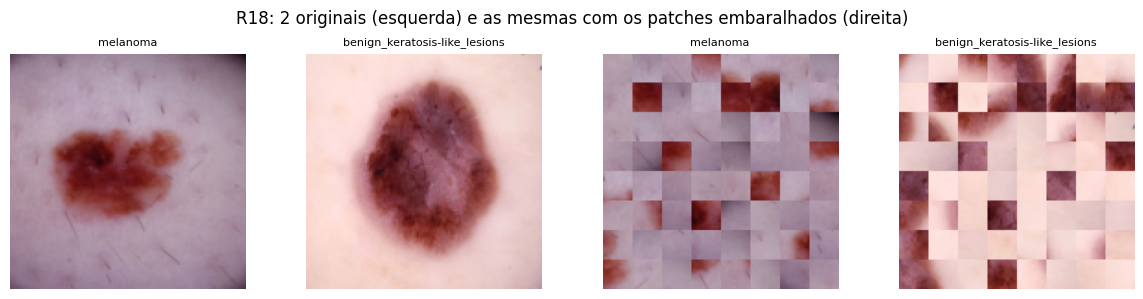

In [13]:
def embaralhar_patches(imgs: torch.Tensor, patch: int, ordem: torch.Tensor) -> torch.Tensor:
    """Reorganiza os patches patch×patch de cada imagem na ordem dada (mesmo conteúdo, outro arranjo)."""
    B, C, H_img, W_img = imgs.shape
    g = H_img // patch
    blocos = imgs.unfold(2, patch, patch).unfold(3, patch, patch).reshape(B, C, g * g, patch, patch)
    blocos = blocos[:, :, ordem]
    return blocos.reshape(B, C, g, g, patch, patch).permute(0, 1, 2, 4, 3, 5).reshape(B, C, H_img, W_img)


with cronometrar("testes R18 (positional encoding)", TEMPOS):
    perm = torch.randperm(N)
    bloco = TransformerEncoderBlock(D, H, CONFIG_ZERO["modelo"]["mlp"]).eval()
    with torch.no_grad():
        testar("R18 bloco sem PE: permutar os tokens só permuta a saída",
               torch.allclose(bloco(x_tok)[0][:, perm], bloco(x_tok[:, perm])[0], atol=1e-5))

    vit = VisionTransformer(**CONFIG_ZERO["modelo"]).eval()
    amostra = x_real[:8]
    ordem = torch.randperm((TAMANHO_ZERO // PATCH_ZERO) ** 2)
    amostra_emb = embaralhar_patches(amostra, PATCH_ZERO, ordem)
    with torch.no_grad():
        muda_com_pe = not torch.allclose(vit(amostra)[0], vit(amostra_emb)[0], atol=1e-4)
        vit.pos.zero_()
        igual_sem_pe = torch.allclose(vit(amostra)[0], vit(amostra_emb)[0], atol=1e-4)
    testar("R18 com PE, embaralhar os patches muda os logits", muda_com_pe)
    testar("R18 sem PE, embaralhar os patches NÃO muda os logits (o modelo vê um 'saco de patches')",
           igual_sem_pe)

# Figura: imagens originais × patches embaralhados (evidência visual para o R18)
fig = figura_batch(torch.cat([amostra[:2], amostra_emb[:2]]), torch.cat([y_real[:2], y_real[:2]]),
                   INDICE_PARA_CLASSE, MEDIA, DESVIO,
                   "R18: 2 originais (esquerda) e as mesmas com os patches embaralhados (direita)", n=4)
fig.savefig(DIR_REPORT_ASSETS / "r18_patches_embaralhados.png", dpi=120, bbox_inches="tight")
display(fig)
plt.close(fig)

In [14]:
# Sanidade antes da Fase 4: o ViT do zero consegue decorar 16 imagens reais (loss -> ~0)?
# Um bug (gradiente que não chega, rótulo desalinhado) deixa a loss parada perto de ln(7) ≈ 1,95.
# Sem dropout e com até 300 passos: imagens reais são parecidas entre si e demoram mais a decorar
# que ruído aleatório; o que importa é a loss cair de forma consistente até perto de zero.
with cronometrar("overfit de 16 imagens (sanidade)", TEMPOS):
    torch.manual_seed(SEED)
    vit = VisionTransformer(**{**CONFIG_ZERO["modelo"], "dropout": 0.0}).to(DEVICE).train()
    xb, yb = x_real[:16].to(DEVICE), y_real[:16].to(DEVICE)
    otimizador = torch.optim.AdamW(vit.parameters(), lr=1e-3)
    historico = []
    for passo in range(300):
        perda = F.cross_entropy(vit(xb)[0], yb)
        otimizador.zero_grad()
        perda.backward()
        otimizador.step()
        historico.append(perda.item())
        if passo % 25 == 0:
            print(f"passo {passo:3d}  loss {perda.item():.4f}")
        if perda.item() < 0.05:
            print(f"passo {passo:3d}  loss {perda.item():.4f}  (parou: abaixo de 0,05)")
            break
    testar(f"overfit: loss {historico[0]:.3f} -> {historico[-1]:.4f} em {len(historico)} passos (< 0,1)",
           historico[-1] < 0.1)
del vit, otimizador

passo   0  loss 1.9515
passo  25  loss 0.4269
passo  50  loss 0.2554
passo  75  loss 0.0820
passo  77  loss 0.0490  (parou: abaixo de 0,05)
OK  overfit: loss 1.951 -> 0.0490 em 78 passos (< 0,1)
[tempo] overfit de 16 imagens (sanidade): 4.5s | pico VRAM 0.15 GB (reservada 0.18 GB) | pico RAM do processo 2.61 GB


## Treino (Fase 4)

Loop em `src/training.py`: AMP fp16 + GradScaler, clipping, warmup + cosseno por passo, AdamW sem
weight decay em bias/LayerNorm/CLS/posição, melhor modelo e early stopping pelo **F1 macro de
validação**, checkpoints `ultimo.pt` (retomada) e `melhor.pt` no Drive. Os dois modelos usam a mesma
`CrossEntropyLoss` com os pesos de classe "balanced" do treino.

O **smoke test** abaixo roda poucos passos para exercitar todo o caminho (treino, validação, F1,
checkpoints, CSV) e medir o tempo por passo e o pico de VRAM antes dos treinos longos.

In [15]:
# Pesos de classe "balanced" (só o treino, por imagem): os mesmos para os dois modelos (R22)
PESOS_CLASSE = computar_pesos(SPLIT_OFICIAL)
print({c: round(p, 3) for c, p in zip(CLASSES, PESOS_CLASSE.tolist())})

PASSOS_SMOKE = 20
with cronometrar(f"smoke test do treino (ViT do zero, {PASSOS_SMOKE} passos x 2 épocas)", TEMPOS):
    torch.manual_seed(SEED)
    vit_smoke = VisionTransformer(**CONFIG_ZERO["modelo"])
    hist_smoke = treinar_modelo(
        vit_smoke, loaders["zero"], PESOS_CLASSE, "smoke_zero",
        checkpoint_dir=DIR_CHECKPOINTS, dir_resultados=DIR_EXPERIMENTOS,
        config_modelo=CONFIG_ZERO["modelo"], **{**CONFIG_ZERO["treino"], "epochs": 2},
        device=DEVICE, forcar_do_zero=True, max_passos=PASSOS_SMOKE,
    )

dir_smoke = DIR_CHECKPOINTS / "smoke_zero"
testar("smoke: ultimo.pt, melhor.pt e concluido.json gravados",
       all((dir_smoke / a).exists() for a in ("ultimo.pt", "melhor.pt", "concluido.json")))
testar("smoke: nenhum .tmp sobrando (gravação atômica)", not list(dir_smoke.glob("*.tmp")))
testar("smoke: histórico em CSV com 2 épocas", pl.read_csv(DIR_EXPERIMENTOS / "historico" / "smoke_zero.csv").height == 2)
testar("smoke: modelo devolvido em eval (pesos do melhor.pt)", not vit_smoke.training)

# Estimativa grosseira de uma época completa, pela 2ª época (a 1ª inclui o início dos workers)
seg_por_passo = hist_smoke["segundos"][-1] / (2 * PASSOS_SMOKE)          # treino + validação
passos_epoca = len(loaders["zero"]["train"]) + len(loaders["zero"]["validation"])
print(f"~{seg_por_passo:.2f} s/passo -> época completa do ViT do zero ≈ {seg_por_passo * passos_epoca / 60:.1f} min")
del vit_smoke

{'basal_cell_carcinoma': 2.739, 'actinic_keratoses': 4.31, 'benign_keratosis-like_lesions': 1.3, 'melanoma': 1.277, 'dermatofibroma': 12.193, 'vascular_lesions': 9.9, 'melanocytic_Nevi': 0.214}
Weight decay: 74 tensores com decay, 102 sem decay.
Treino de 'smoke_zero' em cuda (AMP ativo), até 2 épocas, 20 passos por época.
[smoke_zero] época 1/2 — train_loss=1.9747 val_loss=1.9352 val_f1_macro=0.1446 grad_norm=5.2980 (22.7s)
[smoke_zero] época 2/2 — train_loss=1.8902 val_loss=1.9006 val_f1_macro=0.2019 grad_norm=4.0116 (23.4s)
Treino de 'smoke_zero' concluído. Melhor F1 macro=0.2019 (época 2); modelo com os pesos de '/content/drive/MyDrive/deep_learning_visao_computacional/A1_vision_transformers/outputs/checkpoints/smoke_zero/melhor.pt'.
[tempo] smoke test do treino (ViT do zero, 20 passos x 2 épocas): 47.7s | pico VRAM 0.42 GB (reservada 0.52 GB) | pico RAM do processo 2.61 GB
OK  smoke: ultimo.pt, melhor.pt e concluido.json gravados
OK  smoke: nenhum .tmp sobrando (gravação atômica)


In [16]:
# Diagnóstico do gargalo. Com prefetch, o DataLoader prepara os próximos batches EM PARALELO
# com a GPU: um passo de treino dura o MAIOR dos dois tempos, não a soma. Por isso cada um é
# medido sozinho. Se o DataLoader for mais lento, quem limita o treino é a CPU (decodificar o
# JPEG, resize, augmentation): aumentar o batch não acelera a época.
import torch.nn.functional as F

N_BATCHES_DL = 20
with cronometrar(f"DataLoader sozinho (ViT do zero, {N_BATCHES_DL} batches de treino)", TEMPOS):
    iterador = iter(loaders["zero"]["train"])
    xb, yb = next(iterador)                          # o 1º batch inclui subir os workers
    t0 = time.perf_counter()
    for _ in range(N_BATCHES_DL):
        next(iterador)
    seg_por_batch_dl = (time.perf_counter() - t0) / N_BATCHES_DL
    del iterador

# GPU sozinha: o mesmo passo do treino (AMP fp16 + GradScaler) com um batch fixo já na GPU
with cronometrar(f"GPU sozinha (ViT do zero, {N_BATCHES_DL} passos com batch fixo)", TEMPOS):
    torch.manual_seed(SEED)
    usa_amp = DEVICE == "cuda"
    vit_gpu = VisionTransformer(**CONFIG_ZERO["modelo"]).to(DEVICE).train()
    otim = torch.optim.AdamW(vit_gpu.parameters(), lr=CONFIG_ZERO["treino"]["lr"])
    scaler = torch.amp.GradScaler("cuda", enabled=usa_amp)
    xb, yb = xb.to(DEVICE), yb.to(DEVICE)

    def passo_gpu():
        otim.zero_grad(set_to_none=True)
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=usa_amp):
            perda = F.cross_entropy(vit_gpu(xb)[0], yb)
        scaler.scale(perda).backward()
        scaler.step(otim)
        scaler.update()

    for _ in range(3):                               # aquecimento (kernels, alocador)
        passo_gpu()
    if usa_amp:
        torch.cuda.synchronize()                     # a GPU é assíncrona: espera terminar
    t0 = time.perf_counter()
    for _ in range(N_BATCHES_DL):
        passo_gpu()
    if usa_amp:
        torch.cuda.synchronize()
    seg_por_passo_gpu = (time.perf_counter() - t0) / N_BATCHES_DL
    del vit_gpu, otim, scaler, xb, yb

gargalo = "CPU (DataLoader)" if seg_por_batch_dl > seg_por_passo_gpu else "GPU"
ociosa = max(0.0, 1 - seg_por_passo_gpu / seg_por_batch_dl)
print(f"DataLoader: {seg_por_batch_dl:.3f} s/batch | GPU: {seg_por_passo_gpu:.3f} s/passo "
      f"-> gargalo: {gargalo}; a GPU fica ociosa ~{ociosa:.0%} do tempo de treino")

[tempo] DataLoader sozinho (ViT do zero, 20 batches de treino): 10.6s | pico VRAM 0.04 GB (reservada 0.47 GB) | pico RAM do processo 2.61 GB
[tempo] GPU sozinha (ViT do zero, 20 passos com batch fixo): 2.6s | pico VRAM 0.41 GB (reservada 0.47 GB) | pico RAM do processo 2.61 GB
DataLoader: 0.491 s/batch | GPU: 0.112 s/passo -> gargalo: CPU (DataLoader); a GPU fica ociosa ~77% do tempo de treino


### Treino do ViT do zero (R20)

Configuração em `CONFIG_ZERO` (célula de setup). Batch 64: o diagnóstico acima mostrou que o treino
é limitado pela CPU, então um batch maior não acelera a época, só reduz o número de atualizações.

> **A escrever (R5, R20):** por que esses hiperparâmetros (lr, weight decay, warmup, paciência,
> épocas, batch), citando o histórico abaixo e o diagnóstico do gargalo.

In [17]:
# Treino real do ViT do zero (R20). Rodar esta célula de novo:
# * depois de uma desconexão: retoma do ultimo.pt na época seguinte;
# * depois de concluído: não treina, só carrega o melhor.pt (é o caminho da entrega).
# Mudou algo no CONFIG_ZERO ou no BATCH_SIZE? Mude também o nome (a config salva é conferida).
NOME_ZERO = "vit_zero_v1"

with cronometrar(f"treino do ViT do zero ({NOME_ZERO})", TEMPOS):
    torch.manual_seed(SEED)
    vit_zero = VisionTransformer(**CONFIG_ZERO["modelo"])
    hist_zero = treinar_modelo(
        vit_zero, loaders["zero"], PESOS_CLASSE, NOME_ZERO,
        checkpoint_dir=DIR_CHECKPOINTS, dir_resultados=DIR_EXPERIMENTOS,
        config_modelo=CONFIG_ZERO["modelo"], **CONFIG_ZERO["treino"], device=DEVICE,
    )

# Melhor época segundo a marca de concluído (a mesma que gerou o melhor.pt)
marca_zero = json.loads((DIR_CHECKPOINTS / NOME_ZERO / "concluido.json").read_text(encoding="utf-8"))
registrar_experimento(
    NOME_ZERO, "vit_zero",
    hiperparametros={**CONFIG_ZERO["modelo"], **CONFIG_ZERO["treino"], "batch_size": BATCH_SIZE["zero"]},
    metricas={
        "val_f1_macro_melhor": round(marca_zero["melhor_f1"], 4),
        "epoca_melhor": marca_zero["epoca_melhor"],
        "epocas_treinadas": len(hist_zero["epoca"]),
        "minutos_treino": round(sum(hist_zero["segundos"]) / 60, 1),  # soma das épocas, inclusive retomadas
    },
    dir_resultados=DIR_EXPERIMENTOS,
    notas="ViT do zero, configuração principal",
)

testar(f"{NOME_ZERO}: modelo devolvido em eval com os pesos do melhor.pt", not vit_zero.training)
print(f"Melhor F1 macro de validação: {marca_zero['melhor_f1']:.4f} (época {marca_zero['epoca_melhor']} "
      f"de {len(hist_zero['epoca'])} treinadas)")
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    display(pl.DataFrame(hist_zero))

'vit_zero_v1' já concluído: melhor.pt carregado (época 26, F1 macro de validação=0.4907). Use forcar_do_zero=True para treinar de novo.
[tempo] treino do ViT do zero (vit_zero_v1): 1.8s | pico VRAM 0.06 GB (reservada 0.47 GB) | pico RAM do processo 2.61 GB
Experimento 'vit_zero_v1' registrado em '/content/drive/MyDrive/deep_learning_visao_computacional/A1_vision_transformers/outputs/experimentos/experimentos.csv'.
OK  vit_zero_v1: modelo devolvido em eval com os pesos do melhor.pt
Melhor F1 macro de validação: 0.4907 (época 26 de 36 treinadas)


epoca,train_loss,val_loss,val_f1_macro,grad_norm,batches_overflow,lr,segundos
i64,f64,f64,f64,f64,i64,f64,f64
1,1.888308,1.730633,0.263761,8.440806,0,0.000061,59.733143
2,1.662607,1.559439,0.283609,7.638104,0,0.000121,57.330126
3,1.586972,1.393927,0.293785,6.39136,1,0.000181,58.597961
4,1.590371,1.539775,0.210403,5.727637,1,0.000241,58.873307
5,1.513177,1.453756,0.304388,4.672742,0,0.0003,60.508379
6,1.460567,1.523702,0.272725,4.387406,0,0.0003,58.943118
7,1.411944,1.369002,0.368745,4.553385,0,0.000299,58.398056
8,1.368005,1.386461,0.32689,4.424702,0,0.000297,58.165966
9,1.335398,1.271758,0.401787,4.199666,0,0.000294,58.082905


### ViT pré-treinado: smoke test (R21)

`google/vit-base-patch16-224` com o head de 1000 classes trocado por um de 7 (`src/models.py`) e o
congelamento definido por `blocos_treinaveis` (0 = só o head; 12 = todos os blocos e embeddings).
O smoke test confere o modelo (fp32, tamanho de imagem, parâmetros treináveis, grupos de weight
decay) e mede o tempo por passo e a VRAM com batch 32 antes dos treinos longos.

Os arquivos do smoke test ficam no disco local (`DIR_CHECKPOINTS_LOCAL`): o `melhor.pt` do ViT-base
tem ~344 MB e o `ultimo.pt` ~1 GB, e regravá-los no Drive só ocuparia a cota.

> **A escrever (R4, R21):** por que o `-224` (ImageNet-21k + ajuste no 1k, 224 px) e não o `-in21k`;
> por que ViT-Base/16; o que muda ao trocar o head e o que cada estratégia de congelamento testa.

In [18]:
def montar_vit_pre(blocos_treinaveis: int):
    """Carrega o ViT-B/16 com head novo (semente fixa), congela e devolve (modelo, config_modelo)."""
    modelo, metadados = carregar_vit_pretreinado(REVISAO_CHECKPOINT_PRE, seed=SEED, checkpoint=CHECKPOINT_PRE)
    info_congelamento = congelar(modelo, blocos_treinaveis)
    # O modelo espera o tamanho que os DataLoaders "pre" entregam (trocar um dos dois não daria erro)
    assert metadados["img"] == TAMANHO_PRE, f"modelo espera {metadados['img']} px, DataLoader entrega {TAMANHO_PRE}"
    return modelo, {**metadados, **info_congelamento}


PASSOS_SMOKE_PRE = 20
with cronometrar(f"smoke test do treino (ViT pré-treinado, {PASSOS_SMOKE_PRE} passos x 2 épocas)", TEMPOS):
    vit_pre_smoke, cfg_modelo_smoke = montar_vit_pre(CONFIG_PRE["modelo"]["blocos_treinaveis"])

    testar("pré-treinado: todos os parâmetros em fp32 (o GradScaler exige)",
           all(p.dtype == torch.float32 for p in vit_pre_smoke.parameters()))
    testar(f"pré-treinado: {cfg_modelo_smoke['parametros_treinaveis']:,} de "
           f"{cfg_modelo_smoke['parametros_totais']:,} parâmetros treináveis",
           cfg_modelo_smoke["parametros_treinaveis"] == sum(p.numel() for p in vit_pre_smoke.parameters() if p.requires_grad))
    if CONFIG_PRE["modelo"]["blocos_treinaveis"] == vit_pre_smoke.config.num_hidden_layers:
        # Os nomes do HF (cls_token, position_embeddings) precisam cair no grupo sem weight decay
        grupos = grupos_weight_decay(vit_pre_smoke, CONFIG_PRE["treino"]["weight_decay"])
        ids_sem_decay = {id(t) for t in grupos[1]["params"]}
        emb = vit_pre_smoke.vit.embeddings
        testar("pré-treinado: cls_token e position_embeddings sem weight decay",
               id(emb.cls_token) in ids_sem_decay and id(emb.position_embeddings) in ids_sem_decay)

    hist_smoke_pre = treinar_modelo(
        vit_pre_smoke, loaders["pre"], PESOS_CLASSE, "smoke_pre",
        checkpoint_dir=DIR_CHECKPOINTS_LOCAL, dir_resultados=DIR_EXPERIMENTOS,
        dir_ultimo=DIR_CHECKPOINTS_LOCAL, config_modelo=cfg_modelo_smoke,
        **{**CONFIG_PRE["treino"], "epochs": 2},
        device=DEVICE, forcar_do_zero=True, max_passos=PASSOS_SMOKE_PRE,
    )

dir_smoke_pre = DIR_CHECKPOINTS_LOCAL / "smoke_pre"
testar("smoke_pre: ultimo.pt, melhor.pt e concluido.json gravados",
       all((dir_smoke_pre / a).exists() for a in ("ultimo.pt", "melhor.pt", "concluido.json")))
testar("smoke_pre: modelo devolvido em eval (pesos do melhor.pt)", not vit_pre_smoke.training)
for arquivo in ("melhor.pt", "ultimo.pt"):
    print(f"{arquivo}: {(dir_smoke_pre / arquivo).stat().st_size / 1024**2:.0f} MB")

# Estimativa de uma época completa, pela 2ª época (a 1ª inclui subir os workers). Inclui a
# gravação dos checkpoints no disco local; no Drive o melhor.pt de ~344 MB demora mais.
seg_por_passo_pre = hist_smoke_pre["segundos"][-1] / (2 * PASSOS_SMOKE_PRE)       # treino + validação
passos_epoca_pre = len(loaders["pre"]["train"]) + len(loaders["pre"]["validation"])
min_epoca_pre = seg_por_passo_pre * passos_epoca_pre / 60
print(f"~{seg_por_passo_pre:.2f} s/passo -> época completa ≈ {min_epoca_pre:.1f} min; "
      f"{CONFIG_PRE['treino']['epochs']} épocas ≈ {min_epoca_pre * CONFIG_PRE['treino']['epochs']:.0f} min por experimento")
del vit_pre_smoke
if DEVICE == "cuda":
    torch.cuda.empty_cache()

[transformers] You passed `num_labels=7` which is incompatible to the `id2label` map of length `1000`.


model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([7, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([7])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


ViT carregado: google/vit-base-patch16-224@3f49326e, head 768 -> 7, imagem 224 px, atenção 'sdpa'.
Congelamento: 12/12 blocos treináveis, 85,804,039 de 85,804,039 parâmetros (100.0%).
OK  pré-treinado: todos os parâmetros em fp32 (o GradScaler exige)
OK  pré-treinado: 85,804,039 de 85,804,039 parâmetros treináveis
Weight decay: 74 tensores com decay, 126 sem decay.
OK  pré-treinado: cls_token e position_embeddings sem weight decay
Weight decay: 74 tensores com decay, 126 sem decay.
Treino de 'smoke_pre' em cuda (AMP ativo), até 2 épocas, 20 passos por época.


/content/repo/A1_vision_transformers/src/training.py:441: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[smoke_pre] época 1/2 — train_loss=1.8577 val_loss=1.6382 val_f1_macro=0.2638 grad_norm=10.4301 overflow=1batches (14.6s)
[smoke_pre] época 2/2 — train_loss=1.6611 val_loss=1.5514 val_f1_macro=0.4053 grad_norm=10.0701 (14.6s)
Treino de 'smoke_pre' concluído. Melhor F1 macro=0.4053 (época 2); modelo com os pesos de '/content/local_data/checkpoints/smoke_pre/melhor.pt'.
[tempo] smoke test do treino (ViT pré-treinado, 20 passos x 2 épocas): 58.1s | pico VRAM 3.47 GB (reservada 3.69 GB) | pico RAM do processo 2.69 GB
OK  smoke_pre: ultimo.pt, melhor.pt e concluido.json gravados
OK  smoke_pre: modelo devolvido em eval (pesos do melhor.pt)
melhor.pt: 327 MB
ultimo.pt: 982 MB
~0.36 s/passo -> época completa ≈ 1.6 min; 8 épocas ≈ 13 min por experimento


### Fine-tuning do ViT pré-treinado (R21)

Mesmo loop, mesma loss com pesos de classe e mesmo split do ViT do zero; muda o modelo
(ViT-B/16, 86M parâmetros, 224 px) e a configuração em `CONFIG_PRE`.

> **A escrever (R5, R21):** por que full fine-tuning (e não linear probe/LP-FT), por que lr 5e-5,
> 8 épocas sem early stopping (cosseno até zero) e batch 32, citando o histórico abaixo.


In [19]:
# Fine-tuning real do ViT pré-treinado (R21): google/vit-base-patch16-224 com o head trocado
# (1000 -> 7 classes) e todos os 12 blocos treináveis (full fine-tuning, CONFIG_PRE).
# Rodar esta célula de novo:
# * depois de uma desconexão: retoma do ultimo.pt na época seguinte;
# * depois de concluído: não treina, só carrega o melhor.pt (é o caminho da entrega).
# Checkpoints no Drive: melhor.pt (~330 MB, usado na avaliação e nos attention maps) e
# ultimo.pt (~1 GB, só para retomar; mais lento por época, mas não perde o treino se o runtime cair).
# Mudou algo no CONFIG_PRE ou no BATCH_SIZE? Mude também o nome (a config salva é conferida).

NOME_PRE = "vit_pre_v1"


with cronometrar(f"treino do ViT pré-treinado ({NOME_PRE})", TEMPOS):         
    vit_pre, cfg_modelo = montar_vit_pre(CONFIG_PRE["modelo"]["blocos_treinaveis"])  
    hist_pre = treinar_modelo(
        vit_pre, loaders["pre"], PESOS_CLASSE, NOME_PRE,
        checkpoint_dir=DIR_CHECKPOINTS, dir_resultados=DIR_EXPERIMENTOS,
        config_modelo=cfg_modelo, **CONFIG_PRE["treino"], device=DEVICE     
    )

# Melhor época segundo a marca de concluído (a mesma que gerou o melhor.pt)
marca_pre = json.loads((DIR_CHECKPOINTS / NOME_PRE / "concluido.json").read_text(encoding="utf-8"))
registrar_experimento(
    NOME_PRE, "vit_pre",                                                        
    hiperparametros={**cfg_modelo, **CONFIG_PRE["treino"], "batch_size": BATCH_SIZE["pre"]},  
    metricas={
        "val_f1_macro_melhor": round(marca_pre["melhor_f1"], 4),
        "epoca_melhor": marca_pre["epoca_melhor"],
        "epocas_treinadas": len(hist_pre["epoca"]),
        "minutos_treino": round(sum(hist_pre["segundos"]) / 60, 1),  # soma das épocas, inclusive retomadas
    },
    dir_resultados=DIR_EXPERIMENTOS,
    notas="ViT pré-treinado, configuração principal",                       
)

testar(f"{NOME_PRE}: modelo devolvido em eval com os pesos do melhor.pt", not vit_pre.training)
print(f"Melhor F1 macro de validação: {marca_pre['melhor_f1']:.4f} (época {marca_pre['epoca_melhor']} "
      f"de {len(hist_pre['epoca'])} treinadas)")
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    display(pl.DataFrame(hist_pre))

[transformers] You passed `num_labels=7` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([7, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([7])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


ViT carregado: google/vit-base-patch16-224@3f49326e, head 768 -> 7, imagem 224 px, atenção 'sdpa'.
Congelamento: 12/12 blocos treináveis, 85,804,039 de 85,804,039 parâmetros (100.0%).
'vit_pre_v1' já concluído: melhor.pt carregado (época 5, F1 macro de validação=0.7733). Use forcar_do_zero=True para treinar de novo.
[tempo] treino do ViT pré-treinado (vit_pre_v1): 13.2s | pico VRAM 1.33 GB (reservada 1.48 GB) | pico RAM do processo 2.69 GB
Experimento 'vit_pre_v1' registrado em '/content/drive/MyDrive/deep_learning_visao_computacional/A1_vision_transformers/outputs/experimentos/experimentos.csv'.
OK  vit_pre_v1: modelo devolvido em eval com os pesos do melhor.pt
Melhor F1 macro de validação: 0.7733 (época 5 de 8 treinadas)


epoca,train_loss,val_loss,val_f1_macro,grad_norm,batches_overflow,lr,segundos
i64,f64,f64,f64,f64,i64,f64,f64
1,1.315293,0.805754,0.623945,10.098303,2,0.00005,93.51943
2,0.638056,0.651123,0.627976,8.148273,0,0.000047,96.735985
3,0.383874,0.671933,0.753055,6.155403,0,0.000039,125.637189
4,0.210951,0.680053,0.693049,4.645471,0,0.000029,115.054381
5,0.11304,0.666654,0.773304,3.411875,0,0.000019,117.237809
6,0.056479,0.680296,0.754138,2.485645,0,0.000009,114.706389
7,0.02793,0.763361,0.761211,1.377715,0,0.000002,113.138031
8,0.016728,0.766991,0.762034,0.874946,0,0.0,112.812925


## Avaliação (R2, R3, R22)

**Métrica principal:** F1 macro, que dá o mesmo peso às 7 classes (com `nv` = 67% das imagens, a acurácia seria enganosa). Complementares: F1 weighted, precision/recall por classe e matriz de confusão normalizada por linha (a diagonal é o recall; a de `mel` é a que mais importa).

**Protocolo:**
1. **Validação só confere o pipeline.** Os modelos carregados (pesos do `melhor.pt`) precisam reproduzir o F1 de validação salvo no `concluido.json`. Se não reproduzirem, algo mudou entre o treino e a avaliação (pesos, transform, ordem), e o teste não deve rodar.
2. **Teste roda uma única vez**, nos dois modelos finais, com o mesmo split. Nada do que se vê aqui volta para escolher hiperparâmetros.
3. **Incerteza:** IC 95% por bootstrap reamostrando **lesões** (não imagens), com as mesmas réplicas para os dois modelos (comparação pareada).

As predições saem na ordem de `SPLIT_OFICIAL.filter(split == "test")` (loaders com `shuffle=False`); `ids_do_split` confere isso comparando os rótulos.

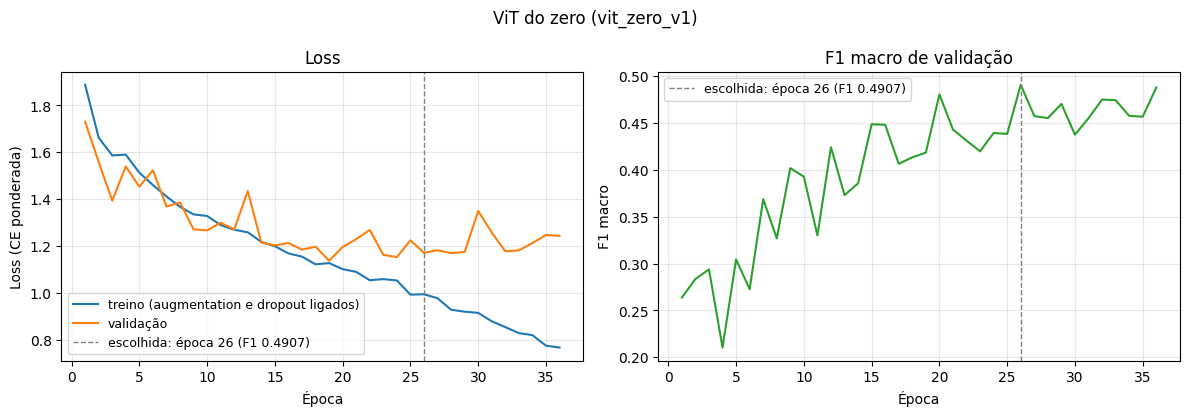

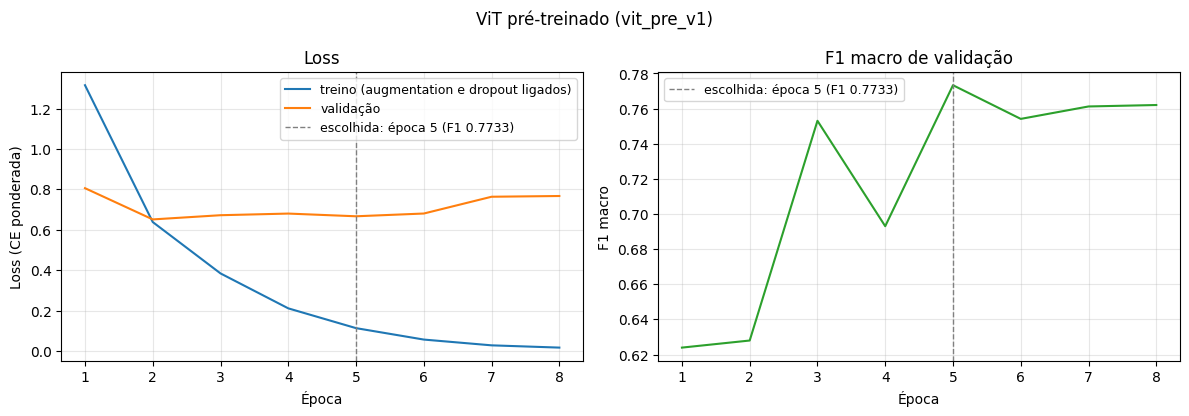

In [20]:
# Curvas de treino: a época marcada vem do concluido.json, a mesma fonte do melhor.pt

NOME_ZERO = "vit_zero_v1"
DIR_FIGURAS = DIR_EXPERIMENTOS / "figuras"
DIR_FIGURAS.mkdir(parents=True, exist_ok=True)

marcas = {NOME_ZERO: ler_marca(DIR_CHECKPOINTS, NOME_ZERO), NOME_PRE: ler_marca(DIR_CHECKPOINTS, NOME_PRE)}
historicos = {NOME_ZERO: hist_zero, NOME_PRE: hist_pre}
titulos_modelos = {NOME_ZERO: "ViT do zero", NOME_PRE: "ViT pré-treinado"}

for nome, hist in historicos.items():
    fig = plotar_curvas(hist, f"{titulos_modelos[nome]} ({nome})", marca=marcas[nome])
    fig.savefig(DIR_FIGURAS / f"curvas_{nome}.png", dpi=150, bbox_inches="tight")
    plt.show()

In [21]:
# Reprodução na validação: cada modelo com o SEU loader (128 px no do zero, 224 px no pré-treinado)
modelos = {NOME_ZERO: vit_zero, NOME_PRE: vit_pre}
loaders_val = {NOME_ZERO: loaders["zero"]["validation"], NOME_PRE: loaders["pre"]["validation"]}

for nome, modelo in modelos.items():
    salvo = marcas[nome]["melhor_f1"]
    y_true_val, y_pred_val, _ = prever(modelo, loaders_val[nome], DEVICE)
    f1_val = calcular_metricas(y_true_val, y_pred_val)["f1_macro"]
    print(f"{nome}: F1 macro de validação {f1_val:.4f} (salvo: {salvo:.4f}, "
          f"época {marcas[nome]['epoca_melhor']})")
    assert abs(f1_val - salvo) < 1e-3, f"{nome}: o modelo carregado não reproduz o F1 salvo"

vit_zero_v1: F1 macro de validação 0.4907 (salvo: 0.4907, época 26)
vit_pre_v1: F1 macro de validação 0.7733 (salvo: 0.7733, época 5)


In [22]:
# Predições no teste: UMA chamada por modelo, cada um com o seu loader
loaders_teste = {NOME_ZERO: loaders["zero"]["test"], NOME_PRE: loaders["pre"]["test"]}

predicoes = {}
with cronometrar("predições no teste", TEMPOS):
    for nome, modelo in modelos.items():
        y_true, y_pred, probs = prever(modelo, loaders_teste[nome], DEVICE)
        predicoes[nome] = {"y_true": y_true, "y_pred": y_pred, "probs": probs}

# Ordem: rótulos do split == y_true de cada modelo, e os dois y_true iguais entre si
lesion_ids, image_ids = ids_do_split(SPLIT_OFICIAL, predicoes[NOME_ZERO]["y_true"], split="test")
ids_do_split(SPLIT_OFICIAL, predicoes[NOME_PRE]["y_true"], split="test")
testar("teste: y_true igual nos dois modelos",
       np.array_equal(predicoes[NOME_ZERO]["y_true"], predicoes[NOME_PRE]["y_true"]))
y_true_teste = predicoes[NOME_ZERO]["y_true"]
print(f"{len(y_true_teste)} imagens de {len(set(lesion_ids))} lesões no teste")

[tempo] predições no teste: 24.7s | pico VRAM 1.36 GB (reservada 1.47 GB) | pico RAM do processo 2.69 GB
OK  teste: y_true igual nos dois modelos
1527 imagens de 1120 lesões no teste


       ViT do zero: F1 macro 0.4257 | F1 weighted 0.6460 | acurácia 0.6058
  ViT pré-treinado: F1 macro 0.7446 | F1 weighted 0.8434 | acurácia 0.8415


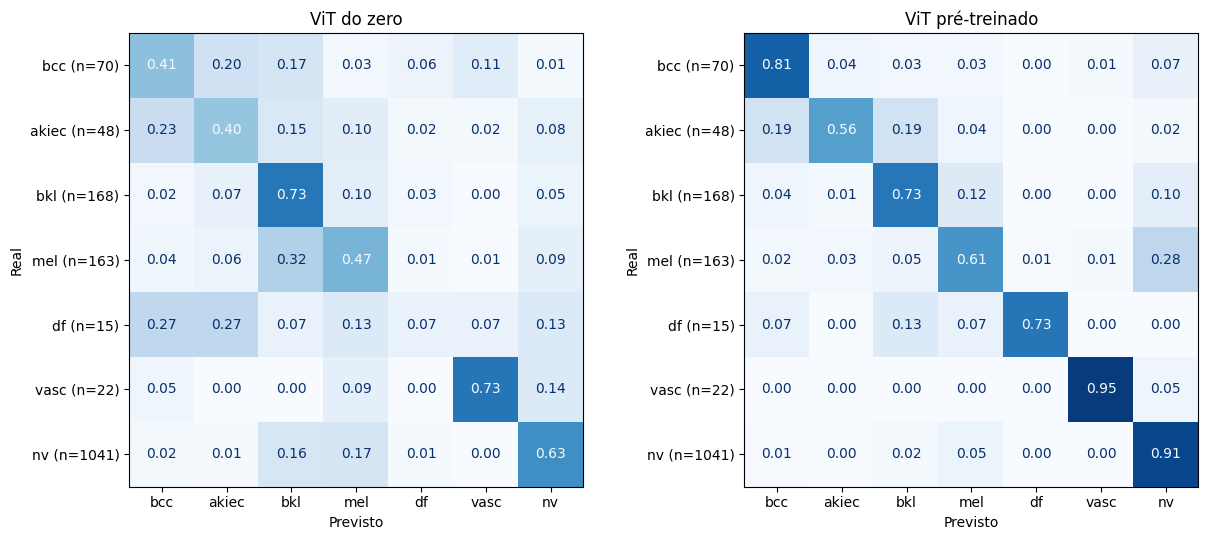

classe,support,precision_ViT do zero,precision_ViT pré-treinado,recall_ViT do zero,recall_ViT pré-treinado,f1_ViT do zero,f1_ViT pré-treinado
str,i64,f64,f64,f64,f64,f64,f64
"""bcc""",70,0.403,0.671,0.414,0.814,0.408,0.735
"""akiec""",48,0.268,0.675,0.396,0.562,0.319,0.614
"""bkl""",168,0.342,0.735,0.726,0.726,0.465,0.731
"""mel""",163,0.279,0.55,0.472,0.607,0.351,0.577
"""df""",15,0.037,0.786,0.067,0.733,0.048,0.759
"""vasc""",22,0.552,0.808,0.727,0.955,0.627,0.875
"""nv""",1041,0.951,0.933,0.635,0.911,0.762,0.922


In [23]:
# Métricas no teste e matrizes de confusão lado a lado (normalizadas por linha: diagonal = recall)
metricas = {nome: calcular_metricas(p["y_true"], p["y_pred"]) for nome, p in predicoes.items()}

for nome, m in metricas.items():
    print(f"{titulos_modelos[nome]:>18}: F1 macro {m['f1_macro']:.4f} | "
          f"F1 weighted {m['f1_weighted']:.4f} | acurácia {m['acuracia']:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, (nome, m) in zip(axes, metricas.items()):
    plotar_matriz_confusao(m["matriz_confusao"], titulo=titulos_modelos[nome], ax=ax)
fig.savefig(DIR_FIGURAS / "matrizes_confusao_teste.png", dpi=150, bbox_inches="tight")
plt.show()

with pl.Config(tbl_rows=-1, tbl_cols=-1):
    display(tabela_por_classe({titulos_modelos[n]: m for n, m in metricas.items()}))

In [24]:
# Baseline + bootstrap pareado por lesão + tabela comparativa (R22)
y_train = np.array([CLASSE_PARA_INDICE[c] for c in SPLIT_OFICIAL.filter(pl.col("split") == "train")["dx"]])
baselines = baseline_dummy(y_train, y_true_teste, seed=SEED)

pareado = bootstrap_pareado(
    y_true_teste, predicoes[NOME_ZERO]["y_pred"],
    predicoes[NOME_PRE]["y_true"], predicoes[NOME_PRE]["y_pred"],
    grupos=lesion_ids, n=1000, seed=SEED, nomes=(NOME_ZERO, NOME_PRE),
)

def resumo_modelo(nome, modelo, loader):
    """Métricas do teste + configuração, tudo lido do que já existe (nada digitado)."""
    hist = historicos[nome]
    return {
        **metricas[nome],
        "ic_f1": pareado[nome],
        "f1_macro_val": marcas[nome]["melhor_f1"],
        "resolucao": loader.dataset[0][0].shape[-1],
        "parametros_treinaveis": sum(p.numel() for p in modelo.parameters() if p.requires_grad),
        "epoca_melhor": marcas[nome]["epoca_melhor"],
        "epocas_treinadas": len(hist["epoca"]),
        "minutos": round(sum(hist["segundos"]) / 60, 1),
        "vram_gb": None,  # TODO: pico de VRAM do treino (TEMPOS ou experimentos.csv)
    }

resultados = {
    "baseline: sempre nv": baselines["most_frequent"]["metricas"],
    "baseline: estratificado": baselines["stratified"]["metricas"],
    **{titulos_modelos[n]: resumo_modelo(n, modelos[n], loaders_teste[n]) for n in modelos},
}
tabela_r22 = tabela_comparativa(resultados)
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    display(tabela_r22)
print(descrever_diferenca(pareado, nomes=(NOME_ZERO, NOME_PRE)))
tabela_r22.write_csv(DIR_EXPERIMENTOS / "tabela_r22_teste.csv")

modelo,f1_macro,f1_ic_2_5,f1_ic_97_5,f1_macro_val,f1_weighted,recall_mel,acuracia,resolucao,parametros_treinaveis,epoca_melhor,epocas_treinadas,minutos,vram_gb
str,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,f64,f64
"""baseline: sempre nv""",0.1158,null,null,null,0.5527,0.0,0.6817,null,null,null,null,null,null
"""baseline: estratificado""",0.1428,null,null,null,0.4782,0.0798,0.4761,null,null,null,null,null,null
"""ViT do zero""",0.4257,0.381,0.4653,0.4907,0.646,0.4724,0.6058,128,2831239,26,36,35.1,null
"""ViT pré-treinado""",0.7446,0.6879,0.7878,0.7733,0.8434,0.6074,0.8415,224,85804039,5,8,14.8,null


Diferença pareada de F1 macro (vit_pre_v1 − vit_zero_v1): +0.3171 [IC 95%: +0.2577; +0.3738], o IC não contém 0; 1000 réplicas por lesão, 0 sem alguma classe.


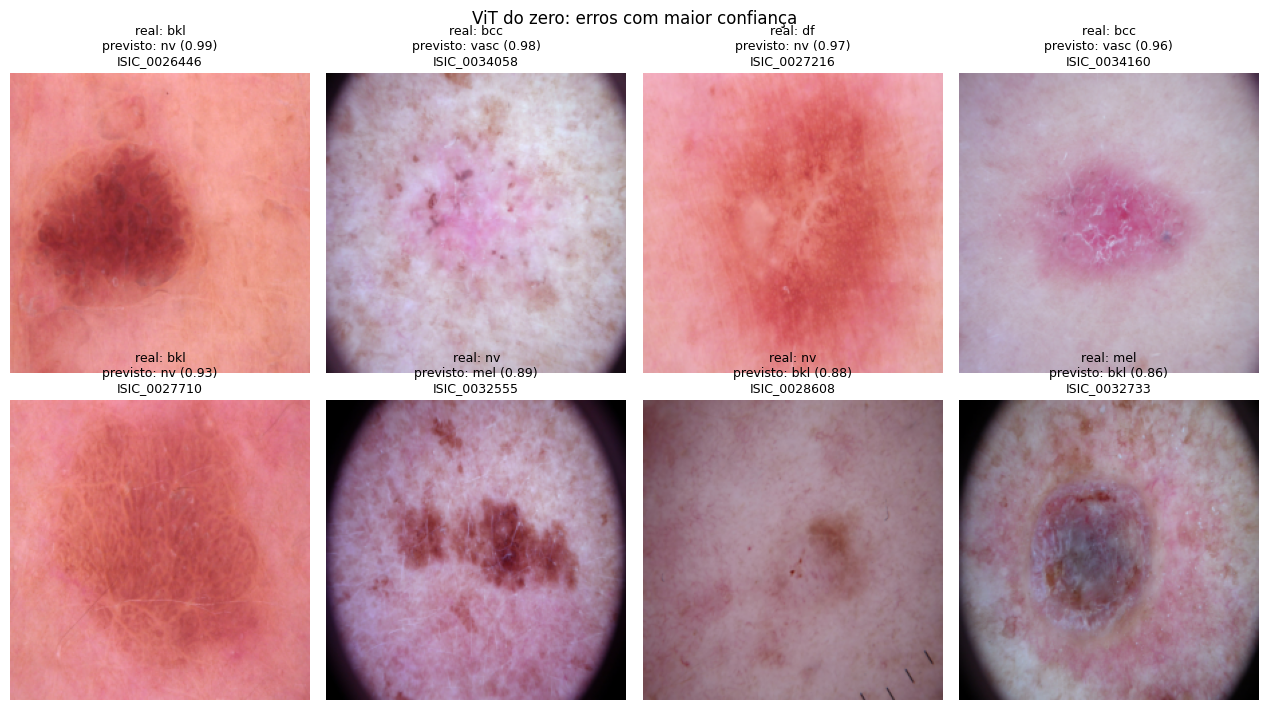

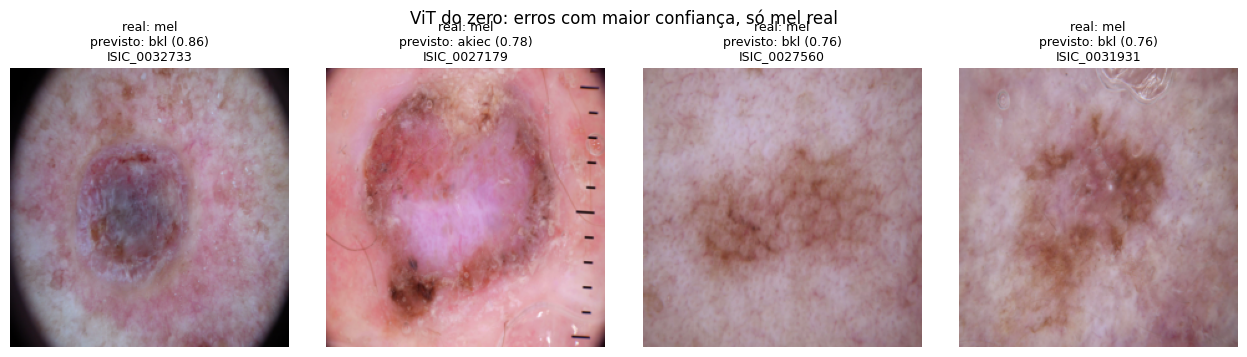

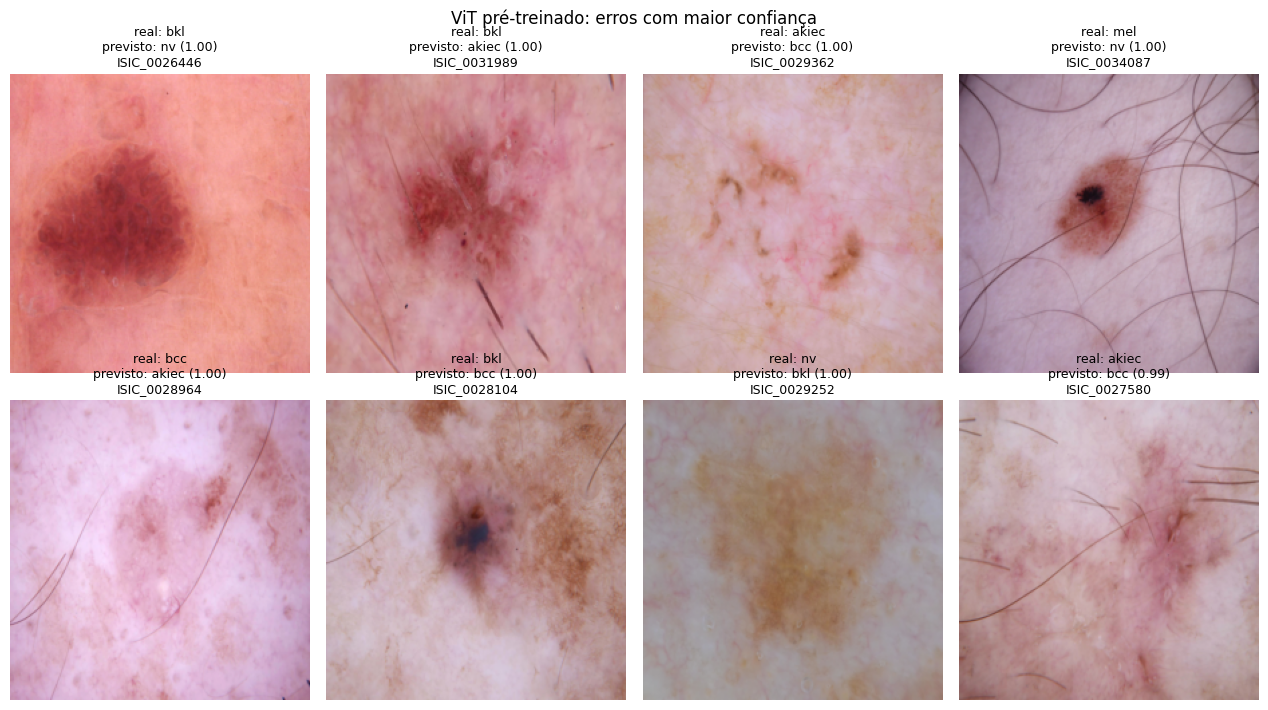

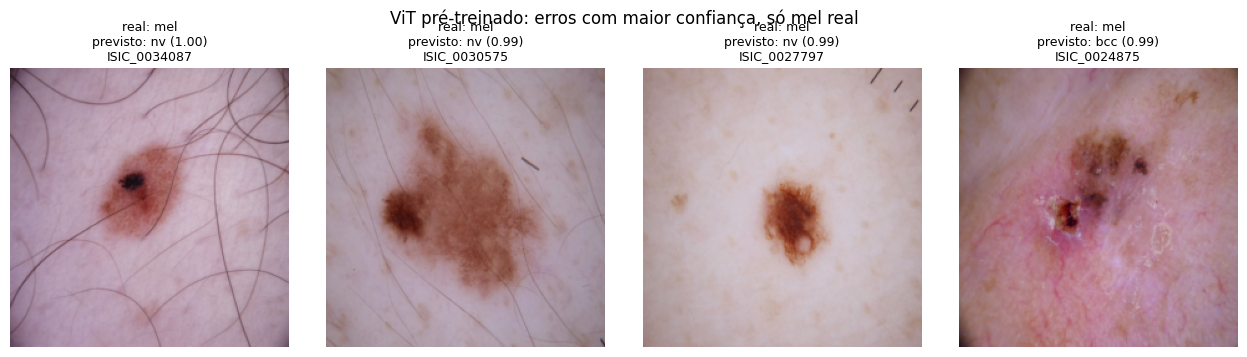

In [25]:
# Erros mais confiantes (um por lesão), sempre exibidos em 224 px, mesmo os do ViT do zero
dataset_224 = loaders["pre"]["test"].dataset

for nome, p in predicoes.items():
    for classe, k in ((None, 8), ("mel", 4)):
        filtro = "" if classe is None else f", só {classe} real"
        fig, mostrados = exemplos_de_erro(
            p["probs"], p["y_true"], dataset_224, lesion_ids, k=k, classe_real=classe,
            image_ids=image_ids, titulo=f"{titulos_modelos[nome]}: erros com maior confiança{filtro}",
        )
        sufixo = "todos" if classe is None else classe
        fig.savefig(DIR_FIGURAS / f"erros_{nome}_{sufixo}.png", dpi=150, bbox_inches="tight")
        plt.show()

## Attention maps (R24, R25, R26)

**O que é mostrado:** a linha do token CLS da última camada, ou seja, quanto o CLS (que vira a
predição) atende a cada patch. O mapa g×g (14×14 no pré-treinado, 8×8 no do zero) é esticado sobre
a imagem sem suavizar (`nearest`), para não sugerir um detalhe que a grade não tem.

**Critério fixo, decidido antes de olhar os mapas** (evita escolher a head ou a imagem "mais bonita"):
- **Imagens:** 1 acerto e 1 erro de `mel` e de `nv` segundo o pré-treinado (sorteio com `SEED`, uma
  foto por lesão) + as 2 imagens do teste com mais patches escuros (vinheta do dermatoscópio), para
  checar o atalho. As mesmas imagens nos dois modelos.
- **Camada:** a última. **Heads:** todas (`plotar_heads`, R24/R26); na comparação lado a lado, a
  média das heads da última camada.
- A escala de cor é **por imagem**; cada painel traz a **concentração** (entropia normalizada:
  1 = atenção uniforme) e a fração que o CLS dá a si mesmo.

**Cuidados de leitura:** atenção alta num patch não prova que ele decidiu a predição (Jain & Wallace,
2019), e ViTs grandes concentram atenção em fundos pouco informativos (Darcet et al., 2023). Por isso
a vinheta é medida (atenção nos patches escuros × fração de patches escuros) e há um teste de
sanidade com um ViT de pesos aleatórios (Adebayo et al., 2018).

> **A escrever (R24, R25, R26):** o que cada modelo pondera (lesão, borda, pele, vinheta, pelos),
> diferença entre acertos e erros, diferença entre os dois modelos e se o ViT do zero se distingue
> do ViT aleatório ("regiões emergentes").

In [ ]:
# Imagens pelo critério fixo e ViT pré-treinado recarregado em "eager" (a SDPA não devolve os pesos)
MEL, NV = CLASSE_PARA_INDICE["melanoma"], CLASSE_PARA_INDICE["melanocytic_Nevi"]

with cronometrar("attention: escolha das imagens e ViT pré-treinado em eager", TEMPOS):
    idx_classes = escolher_exemplos(y_true_teste, predicoes[NOME_PRE]["y_pred"], [MEL, NV],
                                    n_acertos=1, n_erros=1, seed=SEED, grupos=lesion_ids)

    # Vinheta: fração de patches escuros (grade 8×8 sobre a imagem de 128 px) em todo o teste
    fracao_escura = np.concatenate([
        patches_escuros(desnormalizar(x), g=8).mean(axis=(1, 2)) for x, _ in loaders["zero"]["test"]
    ])
    lesoes_usadas = {lesion_ids[i] for i in idx_classes}
    idx_vinheta = []
    for i in np.argsort(-fracao_escura, kind="stable"):
        if lesion_ids[i] not in lesoes_usadas:
            idx_vinheta.append(int(i))
            lesoes_usadas.add(lesion_ids[i])
        if len(idx_vinheta) == 2:
            break
    IDX_ATENCAO = idx_classes + idx_vinheta

    motivos = []
    for i in idx_classes:
        real, pred = y_true_teste[i], predicoes[NOME_PRE]["y_pred"][i]
        motivos.append(f"{sigla(CLASSES[real])}: {'acerto' if real == pred else 'erro'} do pré")
    motivos += [f"vinheta ({fracao_escura[i]:.0%} dos patches escuros)" for i in idx_vinheta]
    print(f"Imagens com vinheta no teste (≥ 1 patch escuro): {(fracao_escura > 0).mean():.0%}")
    for i, motivo in zip(IDX_ATENCAO, motivos):
        print(f"  índice {i:4d} | {image_ids[i]} | lesão {lesion_ids[i]} | {motivo}")

    vit_pre_eager, _ = carregar_vit_pretreinado(REVISAO_CHECKPOINT_PRE, seed=SEED, checkpoint=CHECKPOINT_PRE,
                                                attn_implementation="eager")
    carregar_melhor_modelo(vit_pre_eager, DIR_CHECKPOINTS, NOME_PRE, DEVICE)

# O modelo em eager tem de dar as mesmas predições que o usado na avaliação (sdpa + AMP fp16):
# mesma classe e probabilidades próximas (a diferença vem só do fp16 da avaliação)
probs_eager = atencoes_de_indices(vit_pre_eager, loaders["pre"]["test"].dataset, IDX_ATENCAO, DEVICE)[0]
probs_aval = predicoes[NOME_PRE]["probs"][IDX_ATENCAO]
dif = np.abs(probs_eager - probs_aval).max()
testar(f"eager reproduz as predições do teste (mesma classe; maior diferença de probabilidade {dif:.4f})",
       np.array_equal(probs_eager.argmax(1), probs_aval.argmax(1)) and dif < 0.02)

In [ ]:
# Atenções dos dois modelos nas MESMAS imagens (o do zero em 128 px, o pré-treinado em 224 px)
with cronometrar("attention: extração e figuras", TEMPOS):
    probs_z, at_zero, _, rot_z = atencoes_de_indices(vit_zero, loaders["zero"]["test"].dataset, IDX_ATENCAO, DEVICE)
    probs_p, at_pre, x_pre, rot_p = atencoes_de_indices(vit_pre_eager, loaders["pre"]["test"].dataset, IDX_ATENCAO, DEVICE)
    testar("attention: mesmos rótulos nos dois modelos", np.array_equal(rot_z, rot_p))
    print(f"ViT do zero: {at_zero.shape} | ViT pré-treinado: {at_pre.shape}  (camadas, imagens, heads, tokens, tokens)")

    imagens = desnormalizar(x_pre)  # exibidas em 224 px; o mapa 8×8 vem do mesmo resize quadrado
    titulos = [f"{motivo}\n{t}" for motivo, t in
               zip(motivos, titulos_exemplos(rot_p, {"zero": probs_z, "pré": probs_p}))]

    # R24 e R26: todas as heads da última camada, para a 1ª imagem de mel e a 1ª com vinheta
    for k in (0, len(idx_classes)):
        for nome, at in (("ViT do zero", at_zero), ("ViT pré-treinado", at_pre)):
            fig = plotar_heads(at, imagens[k], indice=k,
                               titulo=f"{nome}: CLS → patches, última camada | {motivos[k]}")
            fig.savefig(DIR_FIGURAS / f"heads_{'zero' if 'zero' in nome else 'pre'}_{IDX_ATENCAO[k]}.png",
                        dpi=150, bbox_inches="tight")
            plt.show()

    # Comparação lado a lado: média das heads da última camada + barras top-3
    mapas = {"ViT do zero": mapa_cls(at_zero, -1), "ViT pré-treinado": mapa_cls(at_pre, -1)}
    fig = plotar_comparacao(imagens, mapas, titulos, probs_por_modelo={"zero": probs_z, "pré": probs_p},
                            titulo="CLS → patches, média das heads da última camada (escala por imagem)")
    fig.savefig(DIR_FIGURAS / "attention_comparacao.png", dpi=150, bbox_inches="tight")
    plt.show()

In [ ]:
# Vinheta (atalho?) e concentração, por imagem e modelo. A máscara de patches escuros é calculada na
# grade de cada modelo sobre a mesma imagem de 224 px, então as frações são comparáveis.
linhas_tabela = []
for nome, at in (("zero", at_zero), ("pré", at_pre)):
    mapa = mapas["ViT do zero" if nome == "zero" else "ViT pré-treinado"]
    escuros = patches_escuros(imagens, g=mapa.shape[-1])
    observada, referencia = fracao_em_patches_escuros(mapa, escuros)
    for k, i in enumerate(IDX_ATENCAO):
        linhas_tabela.append({
            "modelo": nome, "indice": i, "motivo": motivos[k],
            "concentracao": round(float(concentracao(mapa)[k]), 3),
            "cls_para_cls": round(float(massa_no_cls(at, -1)[k]), 3),
            "atencao_nos_escuros": round(float(observada[k]), 3),
            "fracao_de_escuros": round(float(referencia[k]), 3),
        })
tabela_atencao = pl.DataFrame(linhas_tabela)
with pl.Config(tbl_rows=-1, tbl_cols=-1, fmt_str_lengths=60):
    display(tabela_atencao)
tabela_atencao.write_csv(DIR_EXPERIMENTOS / "attention_por_imagem.csv")
print("atencao_nos_escuros ≫ fracao_de_escuros: o CLS atende a vinheta mais do que uma atenção uniforme "
      "atenderia (hipótese de atalho; não prova uso na decisão). NaN = imagem sem patches escuros.")

In [ ]:
# Teste de sanidade (Adebayo et al., 2018): um ViT do zero com pesos ALEATÓRIOS (mesma arquitetura).
# Se os mapas do ViT treinado fossem parecidos com os dele, não daria para falar em regiões
# "aprendidas" (R26). Compara a concentração média das heads da última camada.
torch.manual_seed(SEED)
vit_aleatorio = VisionTransformer(**CONFIG_ZERO["modelo"]).to(DEVICE)
_, at_aleatorio, _, _ = atencoes_de_indices(vit_aleatorio, loaders["zero"]["test"].dataset, IDX_ATENCAO, DEVICE)

def concentracao_por_head(at):
    return np.array([concentracao(mapa_cls(at, -1, h)).mean() for h in range(at.shape[2])])

for nome, at in (("ViT do zero, aleatório", at_aleatorio), ("ViT do zero, treinado", at_zero),
                 ("ViT pré-treinado", at_pre)):
    c = concentracao_por_head(at)
    print(f"{nome:>24}: concentração média por head (1 = uniforme) {np.round(c, 3)} | média {c.mean():.3f}")

fig = plotar_comparacao(imagens[:len(idx_classes)],
                        {"aleatório": mapa_cls(at_aleatorio, -1)[:len(idx_classes)],
                         "zero treinado": mapas["ViT do zero"][:len(idx_classes)]},
                        titulos[:len(idx_classes)],
                        titulo="Sanidade: ViT do zero com pesos aleatórios × treinado (média das heads)")
fig.savefig(DIR_FIGURAS / "attention_sanidade_aleatorio.png", dpi=150, bbox_inches="tight")
plt.show()
del vit_aleatorio, at_aleatorio

In [26]:
# Versões do runtime do Colab: copie a saída para A1_vision_transformers/requirements.txt (R7)
import importlib.metadata as md
pacotes = ["torch", "torchvision", "transformers", "datasets", "polars", "pandas",
           "pyarrow", "scikit-learn", "pillow", "matplotlib"]
print("\n".join(f"{p}=={md.version(p)}" for p in pacotes))

torch==2.11.0+cu128
torchvision==0.26.0+cu128
transformers==5.16.1
datasets==4.8.5
polars==1.35.2
pandas==2.2.3
pyarrow==23.0.1
scikit-learn==1.6.1
pillow==11.3.0
matplotlib==3.10.0


In [27]:
# Resumo de tempo e memória por etapa (R8, R9): copie os totais para a célula do topo
tempos = tabela_tempos(TEMPOS)
display(tempos)
tempos.write_csv(DIR_REPORT_ASSETS / "tempos_execucao.csv")

total_parede = time.perf_counter() - _T_INICIO_NOTEBOOK
print(f"Tempo total desde a primeira célula (inclui pausas entre células): {total_parede / 60:.1f} min")

etapa,segundos,pico_vram_gb,pico_vram_reservada_gb,pico_ram_processo_gb
str,f64,f64,f64,f64
"""clone/pull do repositório""",0.9,null,null,null
"""download/carregamento do datas…",183.9,0.0,0.0,2.61
"""metadados, deduplicação, split…",4.5,0.0,0.0,2.61
"""conferência do split versionad…",0.0,0.0,0.0,2.61
"""DataLoaders e teste de 1 batch""",17.2,0.0,0.0,2.61
…,…,…,…,…
"""treino do ViT do zero (vit_zer…",1.8,0.06,0.47,2.61
"""smoke test do treino (ViT pré-…",58.1,3.47,3.69,2.69
"""treino do ViT pré-treinado (vi…",13.2,1.33,1.48,2.69


Tempo total desde a primeira célula (inclui pausas entre células): 7.2 min


In [28]:
# Copia os artefatos do relatório (tabelas CSV e figuras PNG) para fora do disco temporário.
# /content é apagado quando o runtime é desconectado; rode esta célula ao fim de cada sessão.
import shutil
from datetime import datetime

arquivos = sorted(p.name for p in DIR_REPORT_ASSETS.iterdir() if p.is_file())
print(f"{len(arquivos)} arquivos em {DIR_REPORT_ASSETS}:")
for nome in arquivos:
    print(f"  {nome}")

# 1) Um .zip com report_assets + experimentos (históricos e experimentos.csv), sem os
#    checkpoints .pt, que são grandes (nome com data/hora para não sobrescrever versões anteriores)
staging = Path("/content/_backup_A1")
shutil.rmtree(staging, ignore_errors=True)
shutil.copytree(DIR_REPORT_ASSETS, staging / "report_assets")
if DIR_EXPERIMENTOS.exists():
    shutil.copytree(DIR_EXPERIMENTOS, staging / "experimentos")
carimbo = datetime.now().strftime("%Y%m%d_%H%M")
zip_path = Path(shutil.make_archive(f"/content/artefatos_A1_{carimbo}", "zip", staging))
print(f"\nZip criado: {zip_path} ({zip_path.stat().st_size / 1024:.0f} KB)")

# 2) Se o Drive estiver montado, guarda uma cópia lá (persistente)
DIR_DRIVE_BACKUP = Path("/content/drive/MyDrive/deep_learning_visao_computacional/A1_vision_transformers/report_assets_backup")
if Path("/content/drive/MyDrive").exists():
    DIR_DRIVE_BACKUP.mkdir(parents=True, exist_ok=True)
    shutil.copy2(zip_path, DIR_DRIVE_BACKUP / zip_path.name)
    print(f"Cópia salva no Drive: {DIR_DRIVE_BACKUP / zip_path.name}")
else:
    print("Drive não montado: nenhuma cópia no Drive (use SALVAR_NO_DRIVE = True para montar).")

# 3) Download para o computador (funciona na interface web do Colab)
try:
    from google.colab import files
    files.download(str(zip_path))
except Exception as erro:
    print(f"Download automático indisponível neste ambiente ({type(erro).__name__}).")
    print(f"Baixe manualmente pelo painel de arquivos do Colab: {zip_path}")

13 arquivos em /content/drive/MyDrive/deep_learning_visao_computacional/A1_vision_transformers/outputs/report_assets:
  batch_pre_train.png
  batch_pre_validation.png
  batch_zero_train.png
  batch_zero_validation.png
  contagens.csv
  dx_por_split_antes.csv
  dx_por_split_depois.csv
  r18_patches_embaralhados.png
  tempos_execucao.csv
  vazamento_antes_image_id.csv
  vazamento_antes_lesion_id.csv
  vazamento_depois_image_id.csv
  vazamento_depois_lesion_id.csv

Zip criado: /content/artefatos_A1_20260930_2339.zip (8871 KB)
Cópia salva no Drive: /content/drive/MyDrive/deep_learning_visao_computacional/A1_vision_transformers/report_assets_backup/artefatos_A1_20260930_2339.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>